# 제조데이터 분석 제출 노트북

보고서의 데이터 확인 → EDA → Analysis → Modeling 순서로 핵심 결과를 재현한다.
각 소목차는 질문과 계산 방법, 실행 코드, 실제 표·그림 출력, 결과 해석으로 구성한다.
원본 CSV를 이 폴더에서 읽어 전처리하며, 이후 분석과 현재 모델 학습은 이 자료를 이어서 사용한다.

`requirements.txt` 설치 후 해당 Python 커널을 선택하고 **커널 재시작 및 전체 실행**을 수행한다.
모든 계산 코드는 이 노트북 안에 있으며 별도 Python 소스 파일을 사용하지 않는다.
과거 튜닝은 당시 선택한 설정을 고정해 재학습한다. Optuna 전체 탐색을 다시 수행하지 않는다.
7~8월은 이미 관찰한 자료의 탐색적 재평가이며 새로운 독립 시험이 아니다.

## 실행 환경과 공통 설정

라이브러리는 한 번만 불러온다. 원자료와 결과 경로는 제출 폴더 내부의 상대 경로를 사용한다.

In [1]:
from pathlib import Path
import os
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
import hashlib
import io
import math
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import rankdata
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier, ExtraTreesRegressor
from sklearn.linear_model import LogisticRegression, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from IPython.display import display

PACKAGE = Path.cwd()
if not (PACKAGE / "data/raw/okm_augumented_2021.csv").exists():
    PACKAGE = PACKAGE / "제출"
SOURCE = PACKAGE / "data/raw/okm_augumented_2021.csv"
assert SOURCE.exists(), "제출 폴더에서 노트북을 실행하세요."
OUTPUT = PACKAGE / "output"
OUTPUT.mkdir(exist_ok=True)
SLOTS = ["15분", "30분", "45분", "60분"]
WEATHER = ["기온", "풍속", "습도", "강수량"]
WEATHER_MAP = dict(temperature="기온", wind="풍속", humidity="습도", rain="강수량")
KEYS = ["month", "weekend", "시간"]
COLORS = ["#2878B5", "#D97A27", "#439B80"]
plt.rcParams.update({"font.family": "Malgun Gothic", "axes.unicode_minus": False,
                     "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 12)
def show_figure(name):
    plt.gcf().tight_layout()
    plt.gcf().savefig(OUTPUT / (name + ".png"), dpi=160, bbox_inches="tight")
    plt.show()
def show_table(frame, name):
    frame.to_csv(OUTPUT / (name + ".csv"), index=False, encoding="utf-8-sig")
    display(frame.round(4))
def heatmap(ax, values, xlabels, ylabels, vmin, vmax, cmap="coolwarm", annotate=True, fmt=".1f"):
    im=ax.imshow(values, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(len(xlabels)), xlabels, rotation=0)
    ax.set_yticks(range(len(ylabels)), ylabels)
    if annotate:
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i,j]):
                    ax.text(j,i,f"{values[i,j]:{fmt}}",ha="center",va="center",fontsize=8)
    return im
display(pd.DataFrame({"항목":["Python", "원자료", "결과 저장"],
                      "값":[sys.version.split()[0], str(SOURCE.relative_to(PACKAGE)), "output/"]}))

,항목,값
0,Python,3.13.9
1,원자료,data\raw\okm_augumented_2021.csv
2,결과 저장,output/


# 1. 데이터 확인과 전처리

## 1.1 원본 자료와 EDA 범위

원자료의 규모를 확인하고 1~8월 정상 시간 기록을 공통 분석 자료로 만든다. 시간 오류는 별도로 보존하며 결측·0·극단값은 임의로 바꾸지 않는다.

In [2]:
raw_data = pd.read_csv(SOURCE, encoding="utf-8-sig")
assert hashlib.sha256(SOURCE.read_bytes()).hexdigest() == "8f7af2e49366c93e1d6f5fdef4b5e350066c1792ac463c2c2886e370f4674830"
raw_data["날짜"] = pd.to_numeric(raw_data["날짜"], errors="raise").astype(int)
raw_data["시간"] = pd.to_numeric(raw_data["시간"], errors="raise").astype(int)
scoped = raw_data.loc[raw_data["날짜"].between(20210101,20210831)].copy()
invalid = scoped.loc[~scoped["시간"].between(0,23)].copy()
data = scoped.loc[scoped["시간"].between(0,23)].copy()
data["date"] = pd.to_datetime(data["날짜"].astype(str), format="%Y%m%d")
data["timestamp"] = data.date + pd.to_timedelta(data["시간"],unit="h")
data = data.sort_values("timestamp").reset_index(drop=True)
assert data.timestamp.is_unique
assert data.groupby("date")["시간"].apply(lambda x:set(x)==set(range(24))).all()
data["month"] = data.date.dt.month
data["weekend"] = data.date.dt.dayofweek.ge(5).astype(int)
data["level"] = data[SLOTS].mean(axis=1)
data["maximum"] = data[SLOTS].max(axis=1)
data["slot_range"] = data[SLOTS].max(axis=1)-data[SLOTS].min(axis=1)
data["week"] = data.date-pd.to_timedelta(data.date.dt.dayofweek,unit="D")
(PACKAGE/"data/processed").mkdir(exist_ok=True)
data.to_csv(PACKAGE/"data/processed/정상시간_전처리자료.csv", index=False, encoding="utf-8-sig",float_format="%.17g")
invalid.to_csv(OUTPUT/"제외한_시간오류.csv",index=False,encoding="utf-8-sig")
scope_table=pd.DataFrame({"범위":["원본 전체","1~8월","시간 오류","정상 분석 자료","9월 범위 밖"],
    "행 수":[len(raw_data),len(scoped),len(invalid),len(data),len(raw_data)-len(scoped)]})
show_table(scope_table,"01_분석범위")

,범위,행 수
0,원본 전체,6168
1,1~8월,5832
2,시간 오류,48
3,정상 분석 자료,5784
4,9월 범위 밖,336


**결과 해석**

원본은 6,168행·18열이다. 1~8월 5,832행에서 시간 오류 48행을 제외한 5,784시간·241일을 사용한다. 9월 336행은 기간 범위 밖이며 오류로 제거한 행이 아니다. 이후 분석은 위에서 만든 `data`를 사용한다.

## 1.2 변수의 의미와 계산 관계

CSV 평균의 반올림 관계와 공장인원의 계산 관계를 확인한다. 관찰 변수의 의미와 예측 시점에 사용할 수 있는 정보를 구분한다.

In [3]:
slot_mean=raw_data[SLOTS].mean(axis=1)
rounded=np.floor(slot_mean+.5)
ratio=raw_data["생산량"]/raw_data[SLOTS].sum(axis=1).replace(0,np.nan)
known=raw_data["공장인원"].notna()
variable_checks=pd.DataFrame({"점검":["평균 = floor(네 값 평균 + 0.5)","공장인원 = 생산량 / 네 전력값 합"],
    "비교 행 수":[len(raw_data),int(known.sum())],
    "최대 절대 차이":[float(abs(rounded-raw_data["평균"]).max()),float(abs(ratio[known]-raw_data.loc[known,"공장인원"]).max())]})
show_table(variable_checks,"02_변수계산관계")
display(pd.DataFrame({"변수":["네 15분 전력", "CSV 평균", "생산량", "기상", "날짜·시간", "공장인원"],
    "사용":["목표 최대값·과거 전력 입력", "EDA 수준 비교", "관계 탐색·직전 생산 입력", "관계 탐색·과거 기상 후보", "정확한 시차·달력", "별도 외부 조건에서 제외"]}))

,점검,비교 행 수,최대 절대 차이
0,평균 = floor(네 값 평균 + 0.5),6168,0.0
1,공장인원 = 생산량 / 네 전력값 합,6151,0.0


,변수,사용
0,네 15분 전력,목표 최대값·과거 전력 입력
1,CSV 평균,EDA 수준 비교
2,생산량,관계 탐색·직전 생산 입력
3,기상,관계 탐색·과거 기상 후보
4,날짜·시간,정확한 시차·달력
5,공장인원,별도 외부 조건에서 제외


**결과 해석**

평균은 네 값의 산술평균을 정수로 반올림한 값이다. 공장인원은 생산량/전력합과 저장 오차 수준으로 일치하므로 실제 근무 인원으로 해석하지 않는다. 구간 차이·시차 분석에는 반올림 전 평균을 사용한다. 목표 시간의 실측 전력·생산량·날씨는 예측 입력에 넣지 않는다. 원단위와 설비 운전 원인은 현 자료에서 미식별이다.

## 1.3 결측 확인과 처리

어느 변수의 어느 시간에 결측이 있는지 확인한다. 관계 분석에서 필요한 변수의 결측만 제외한다.

In [4]:
missing=raw_data.isna().sum().rename("결측 셀 수").rename_axis("변수").reset_index()
show_table(missing.loc[missing["결측 셀 수"].gt(0)],"03_결측수")
missing_rows=data.loc[data[WEATHER+["공장인원"]].isna().any(axis=1),["timestamp"]+WEATHER+["공장인원"]]
show_table(missing_rows,"03_결측위치")

,변수,결측 셀 수
9,풍속,3
11,강수량,1
16,공장인원,17


C:\Users\swoo6\AppData\Local\Temp\ipykernel_32432\920274431.py:49: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(frame.round(4))


,timestamp,기온,풍속,습도,강수량,공장인원
552,2021-01-24 00:00:00,9.8,3.9,66,NaN,0.0000
3625,2021-06-01 01:00:00,15.3,NaN,98,0.0,0.2030
3626,2021-06-01 02:00:00,15.2,NaN,96,0.0,0.3261
4436,2021-07-04 20:00:00,25.4,NaN,81,24.7,0.0000
5706,2021-08-28 18:00:00,25.9,0.7,81,0.2,NaN
5707,2021-08-28 19:00:00,25.4,0.3,88,0.2,NaN
5708,2021-08-28 20:00:00,24.8,1.2,90,0.2,NaN
5709,2021-08-28 21:00:00,24.3,1.2,91,0.2,NaN
5710,2021-08-28 22:00:00,24.4,1.5,89,0.2,NaN
5711,2021-08-28 23:00:00,24.3,1.1,83,0.2,NaN


**결과 해석**

결측은 풍속 3셀, 강수량 1셀, 공장인원 17셀이다. 전력·생산량에는 결측이 없다. 보간하거나 0으로 채우지 않는다. 공장인원 17셀은 전력과 생산량이 모두 0인 0/0 기록이며, 해당 시간의 전력 기록은 유지한다.

## 1.4 시간 오류·극단값·0값의 처리

시간 오류와 분포상 큰 값의 차이를 점검한다. IQR 밖이라는 이유만으로 관측을 삭제하지 않는다.

In [5]:
rows=[]
for col in ["생산량","강수량"]:
    v=scoped[col].dropna(); q1,q3=v.quantile([.25,.75]); width=q3-q1
    rows.append({"변수":col,"관측 수":len(v),"0 비율(%)":100*v.eq(0).mean(),"IQR":width,
                 "IQR 기준 밖":int((v.lt(q1-1.5*width)|v.gt(q3+1.5*width)).sum()),"최댓값":v.max()})
show_table(pd.DataFrame(rows),"04_분포점검")
show_table(invalid.groupby("날짜")["시간"].agg(["size","min","max"]).reset_index(),"04_시간오류")
print("네 전력값 모두 0인 정상 시간:",int(data[SLOTS].eq(0).all(axis=1).sum()))

,변수,관측 수,0 비율(%),IQR,IQR 기준 밖,최댓값
0,생산량,5832,43.8100,628.5,533,9830.0
1,강수량,5831,75.2701,0.0,1442,122.4


,날짜,size,min,max
0,20210713,24,70,188
1,20210715,24,74,184


네 전력값 모두 0인 정상 시간: 17


**결과 해석**

7월 13일·15일 48행의 시간은 70~188로 정상 시각을 식별할 수 없어 제외한다. 생산량 극단값과 양수 강수는 유지한다. 강수 IQR이 0이므로 IQR 기준을 삭제 규칙으로 쓰면 모든 양수 강수를 제거하게 된다. 전력 네 값이 모두 0인 17시간도 유지하며 그 원인을 추정하지 않는다.

## 1.5 반복 기록과 최종 분석 자료

날짜가 다른 동일한 96개 전력 배열을 확인하고 요일별 분석 분모를 확정한다.

In [6]:
daily_profiles={date:hashlib.sha256(g[SLOTS].to_numpy(dtype=np.int64).tobytes()).hexdigest()
                for date,g in data.groupby("date")}
data["profile"]=data.date.map(daily_profiles)
profile_counts=pd.Series(daily_profiles).value_counts()
data["profile_weight"]=1/data.profile.map(profile_counts)
summary=pd.DataFrame({"항목":["완전 중복 원본 행","정상 날짜","서로 다른 하루 배열","반복 그룹 날짜","하루 생산량 여러 값", "원본 생산량 0", "생산량 0이면서 양수 전력"],
    "수":[raw_data.duplicated().sum(),data.date.nunique(),len(profile_counts),profile_counts[profile_counts.gt(1)].sum(),
           data.groupby("date")["생산량"].nunique().gt(1).sum(),raw_data["생산량"].eq(0).sum(),
           (raw_data["생산량"].eq(0)&raw_data["평균"].gt(0)).sum()]})
show_table(summary,"05_반복기록")
show_table(data.groupby("weekend").agg(날짜수=("date","nunique"),시간수=("timestamp","size")).reset_index(),"05_요일범위")
processed_data = data.copy()

,항목,수
0,완전 중복 원본 행,0
1,정상 날짜,241
2,서로 다른 하루 배열,126
3,반복 그룹 날짜,160
4,하루 생산량 여러 값,181
5,원본 생산량 0,2657
6,생산량 0이면서 양수 전력,2640


,weekend,날짜수,시간수
0,0,171,4104
1,1,70,1680


**결과 해석**

241일의 서로 다른 전력 배열은 126개이고 160일이 반복 그룹에 속한다. 날짜별 생산량·날씨가 동일한 완전 중복 행은 아니므로 날짜를 삭제하지 않는다. 평일은 171일·4,104시간, 주말은 70일·1,680시간이다. 반복 원인은 현 자료에서 미식별이며 민감도 비교에서는 역빈도 가중으로 반복 배열의 비중을 점검한다.

# 2. EDA

## 2.1 평일·주말의 생산량과 전력 하루 패턴

같은 시간대의 생산량과 CSV 평균 전력을 요일 집단별로 평균한다. 서로 다른 단위는 축을 분리한다.

,weekend,시간,생산량,평균
8,0,8,615.5205,150.8772
11,0,11,1249.6842,150.5731
12,0,12,425.1813,93.6959
13,0,13,1165.8713,148.2573
19,0,19,1861.2865,120.3216
32,1,8,0.2000,46.7286
35,1,11,0.1714,44.3286
36,1,12,0.0000,35.2143
37,1,13,0.0000,43.9143
43,1,19,0.0000,41.1143


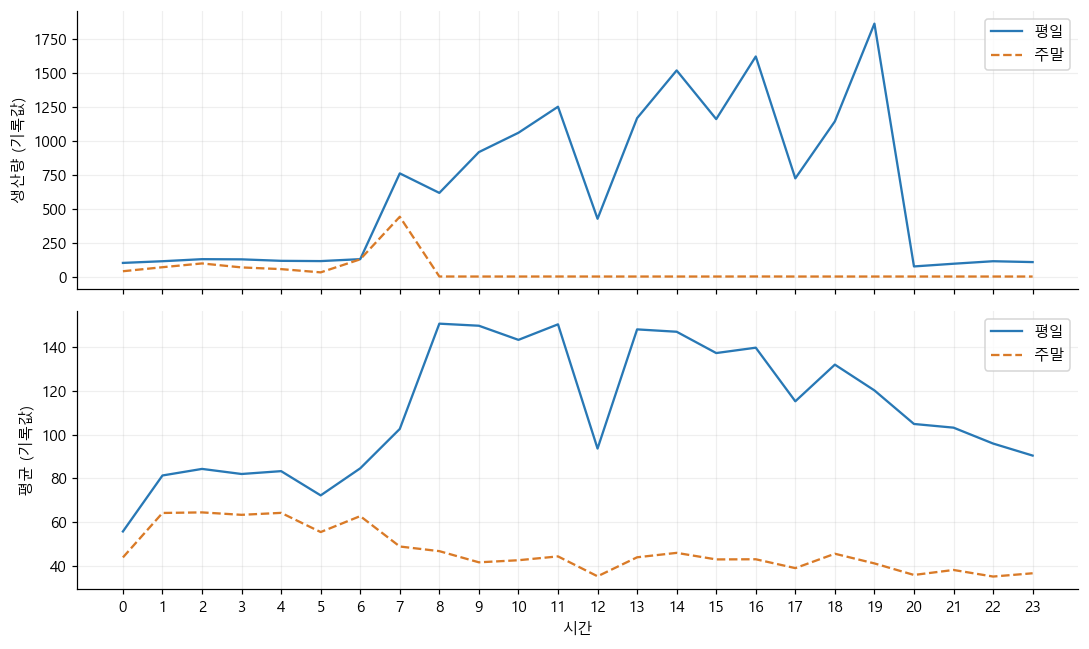

In [7]:
hourly=data.groupby(["weekend","시간"])[["생산량","평균"]].mean().reset_index()
show_table(hourly.loc[hourly["시간"].isin([8,11,12,13,19])],"06_시간대평균")
fig,axes=plt.subplots(2,1,figsize=(10,6),sharex=True)
for group,label,color in [(0,"평일",COLORS[0]),(1,"주말",COLORS[1])]:
    g=hourly.loc[hourly.weekend.eq(group)]
    for ax,col in zip(axes,["생산량","평균"]):
        ax.plot(g["시간"],g[col],label=label,color=color,linestyle="-" if group==0 else "--")
        ax.set_ylabel(col+" (기록값)");ax.grid(alpha=.2);ax.legend()
axes[-1].set_xticks(range(24));axes[-1].set_xlabel("시간")
show_figure("06_하루패턴")

**결과 해석**

평일 두 값은 12시에 낮아지고 13시에 다시 높아진다. 생산량 최고 시간은 19시, 전력 최고 시간은 08시로 서로 다르다. 주말 19시 생산량은 모두 0이지만 전력 평균은 41.11이다. 생산량만으로 전력 패턴을 설명하기 어렵고 시간대·요일을 함께 고려해야 한다.

## 2.2 날짜별 차이와 월별 전력 수준

평균선이 모든 날짜를 대표하는지 분포와 월별 평균을 함께 확인한다. 생산량 0인 날짜도 포함한다.

,집단,전체 날짜,12시 하락·13시 상승,11→12 중앙값,12→13 중앙값
0,평일,171,147,-64.0,61.0
1,주말,70,13,-1.0,0.0


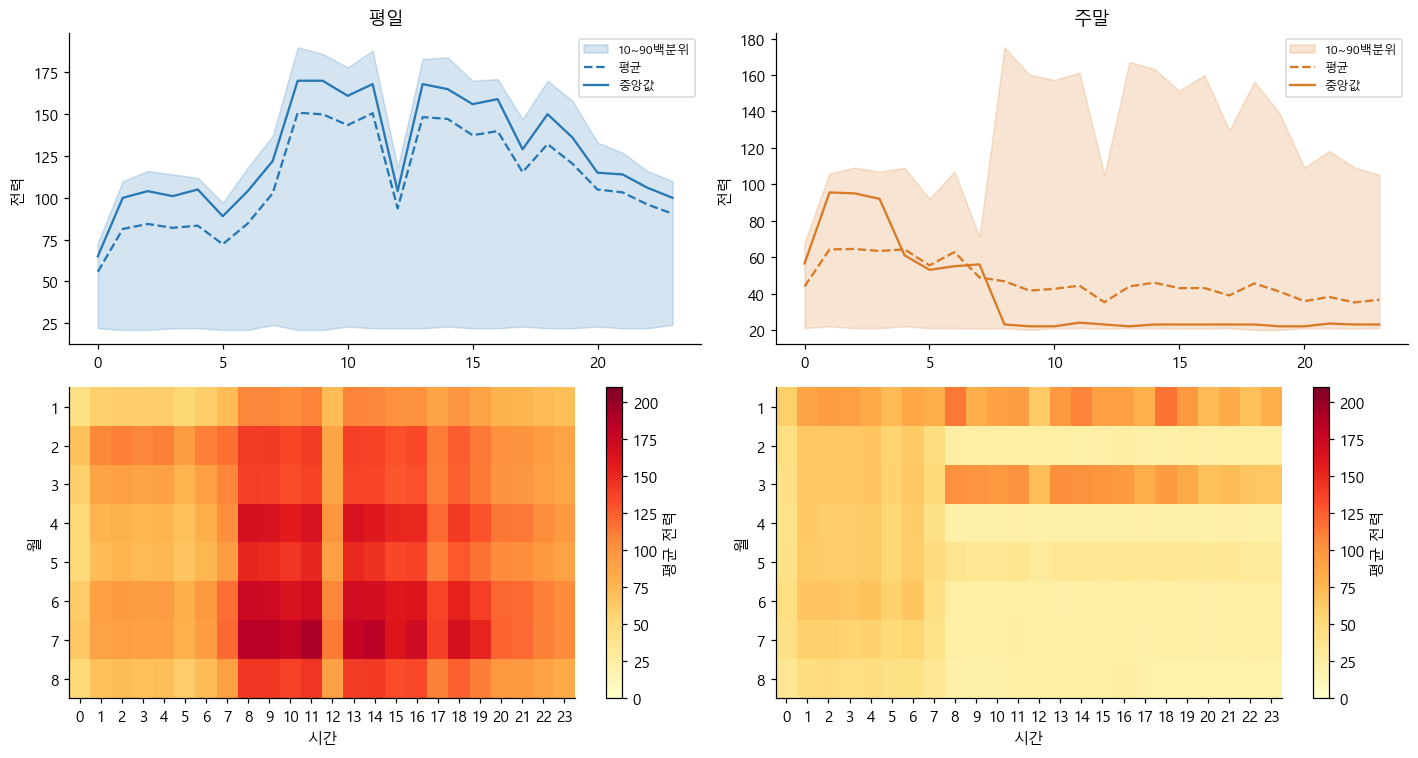

In [8]:
day_power=data.pivot(index="date",columns="시간",values="평균")
day_production=data.groupby("date")["생산량"].max()
lunch=(day_power[12]<day_power[11])&(day_power[13]>day_power[12])
rows=[]
for group,label in [(0,"평일"),(1,"주말")]:
    dates=data.loc[data.weekend.eq(group),"date"].unique();p=day_power.loc[dates]
    rows.append({"집단":label,"전체 날짜":len(p),"12시 하락·13시 상승":int(lunch.loc[dates].sum()),
                 "11→12 중앙값":(p[12]-p[11]).median(),"12→13 중앙값":(p[13]-p[12]).median()})
show_table(pd.DataFrame(rows),"07_날짜별패턴")
fig,axes=plt.subplots(2,2,figsize=(13,7))
for group,label in [(0,"평일"),(1,"주말")]:
    p=data.loc[data.weekend.eq(group)].groupby("시간")["평균"]
    q=p.quantile([.1,.9]).unstack(); ax=axes[0,group]
    ax.fill_between(q.index,q[.1],q[.9],alpha=.2,color=COLORS[group],label="10~90백분위")
    ax.plot(p.mean(),ls="--",color=COLORS[group],label="평균")
    ax.plot(p.median(),color=COLORS[group],label="중앙값");ax.set_title(label);ax.legend(fontsize=8);ax.set_ylabel("전력")
    matrix=data.loc[data.weekend.eq(group)].pivot_table(index="month",columns="시간",values="평균",aggfunc="mean")
    im=heatmap(axes[1,group],matrix.to_numpy(),list(range(24)),matrix.index,0,210,"YlOrRd",False)
    axes[1,group].set_xlabel("시간");axes[1,group].set_ylabel("월");fig.colorbar(im,ax=axes[1,group],label="평균 전력")
show_figure("07_날짜와월별차이")

**결과 해석**

평일 147/171일, 주말 13/70일에 12시 하락·13시 상승이 나타난다. 음영은 날짜별 분포이며 신뢰구간이 아니다. 평균과 중앙값의 차이는 같은 시간대에 낮고 높은 날짜가 섞였음을 보여준다. 8월 평일의 낮은 평균에는 생산량이 하루 내내 0인 5일의 구성도 포함돼 있다.

### 실제 시간순 전력과 낮은 구간의 지속

관측 공백에서 선을 끊고 월별 실제 평균·최대값을 표시한다. 낮은 구간의 연속 기록은 공백을 넘어 연결하지 않는다.

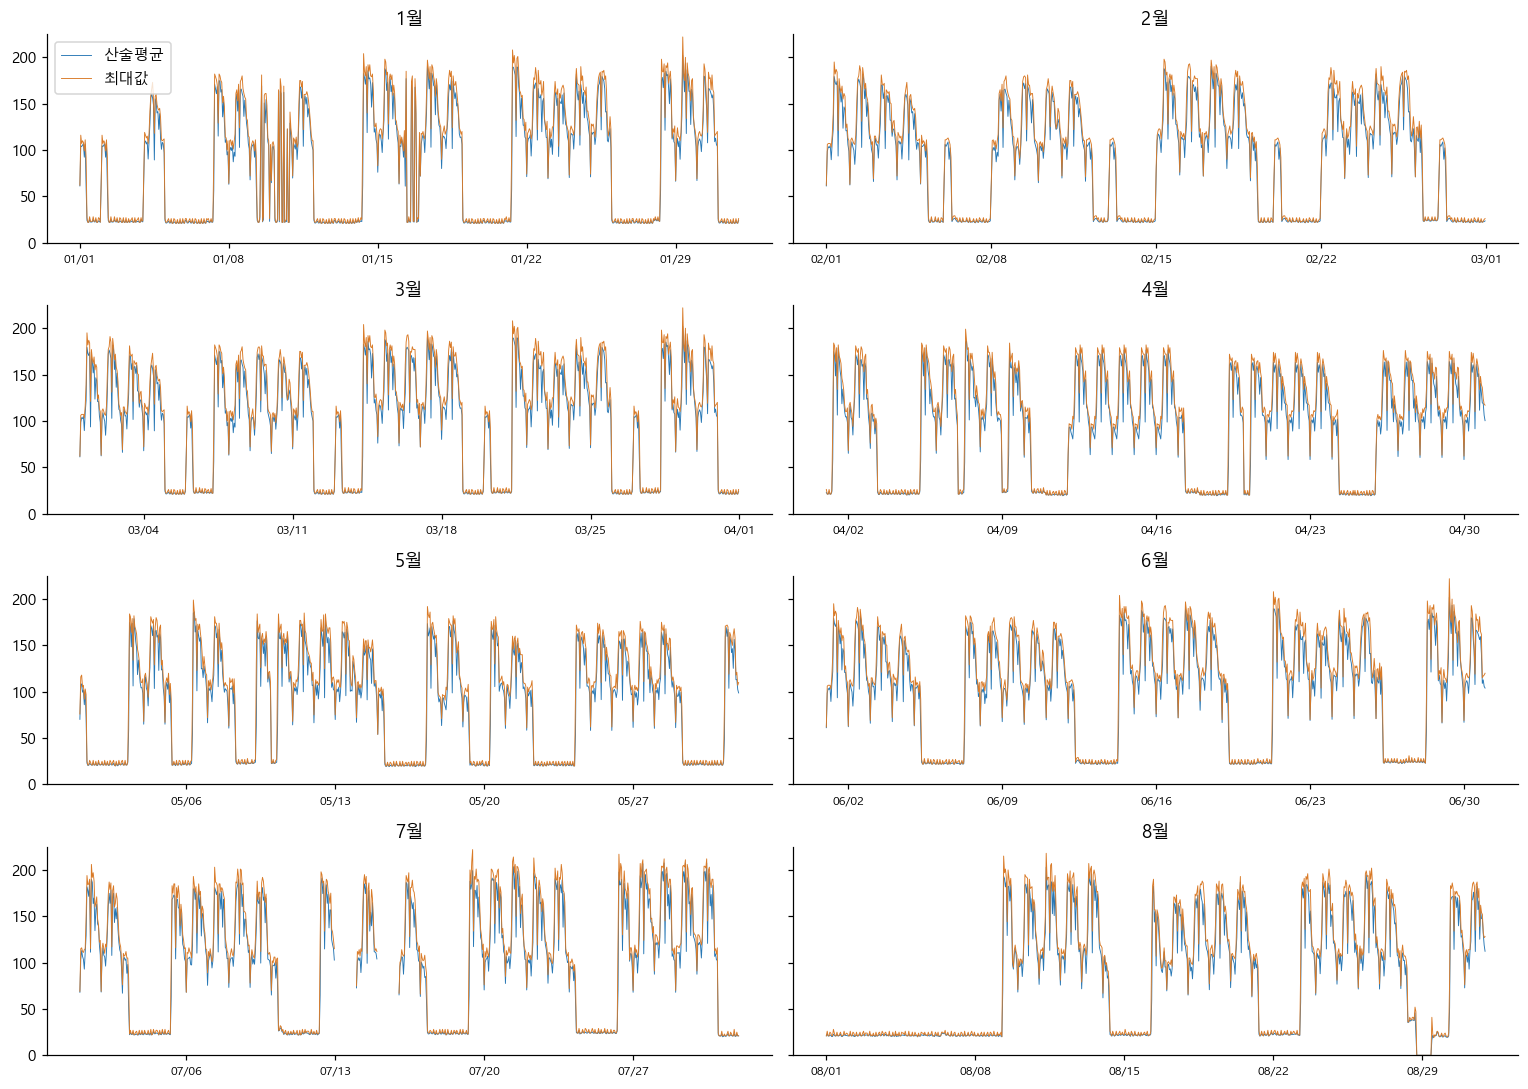

C:\Users\swoo6\AppData\Local\Temp\ipykernel_32432\920274431.py:49: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(frame.round(4))


,시작,종료,지속시간
0,2021-07-31,2021-08-09 06:00:00,223
1,2021-01-12,2021-01-14 06:00:00,55
2,2021-01-05,2021-01-07 06:00:00,55
3,2021-01-19,2021-01-21 06:00:00,55
4,2021-01-26,2021-01-28 06:00:00,55


In [9]:
grid=data.set_index("timestamp").reindex(pd.date_range("2021-01-01","2021-08-31 23:00",freq="h"))
fig,axes=plt.subplots(4,2,figsize=(14,10),sharey=True)
for month,ax in zip(range(1,9),axes.flat):
    g=grid.loc[grid.index.month==month]
    ax.plot(g.index,g.level,label="산술평균",lw=.6,color=COLORS[0]);ax.plot(g.index,g.maximum,label="최대값",lw=.6,color=COLORS[1])
    ax.set_title(f"{month}월");ax.set_ylim(0,225)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7));ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"));ax.tick_params(axis="x",labelsize=8)
axes[0,0].legend();show_figure("08_월별실제전력")
low=grid["평균"].between(20,26)
segments=(low.ne(low.shift())).cumsum()
episodes=grid.loc[low].groupby(segments[low]).apply(lambda g:pd.Series({"시작":g.index.min(),"종료":g.index.max(),"지속시간":len(g)}),include_groups=False)
show_table(episodes.sort_values("지속시간",ascending=False).head(5).reset_index(drop=True),"08_낮은구간지속")

**결과 해석**

낮은 수준이 이어지는 기간과 높은 값이 반복되는 기간이 함께 있다. 공백 시각은 보간하지 않는다. 지속시간은 정상 시각의 연속 기록 수이며 실제 설비 정지 시간을 뜻하지 않는다. 이후 분석은 낮은 구간의 출입뿐 아니라 높은 구간 안의 추가 상승·하락도 포함한다.

## 2.3 생산량·날씨와 전력의 관계

전체와 월별 Spearman 순위상관을 비교한다. 변수별 결측은 해당 쌍에서만 제외한다.

,변수,생산량,기온,풍속,습도,강수량,평균
0,생산량,1.0000,0.1136,0.0888,-0.0853,-0.0057,0.7520
1,기온,0.1136,1.0000,-0.1557,0.3522,0.1584,0.0578
2,풍속,0.0888,-0.1557,1.0000,-0.4361,0.0085,0.1371
3,습도,-0.0853,0.3522,-0.4361,1.0000,0.4574,-0.1187
4,강수량,-0.0057,0.1584,0.0085,0.4574,1.0000,-0.0140
5,평균,0.7520,0.0578,0.1371,-0.1187,-0.0140,1.0000


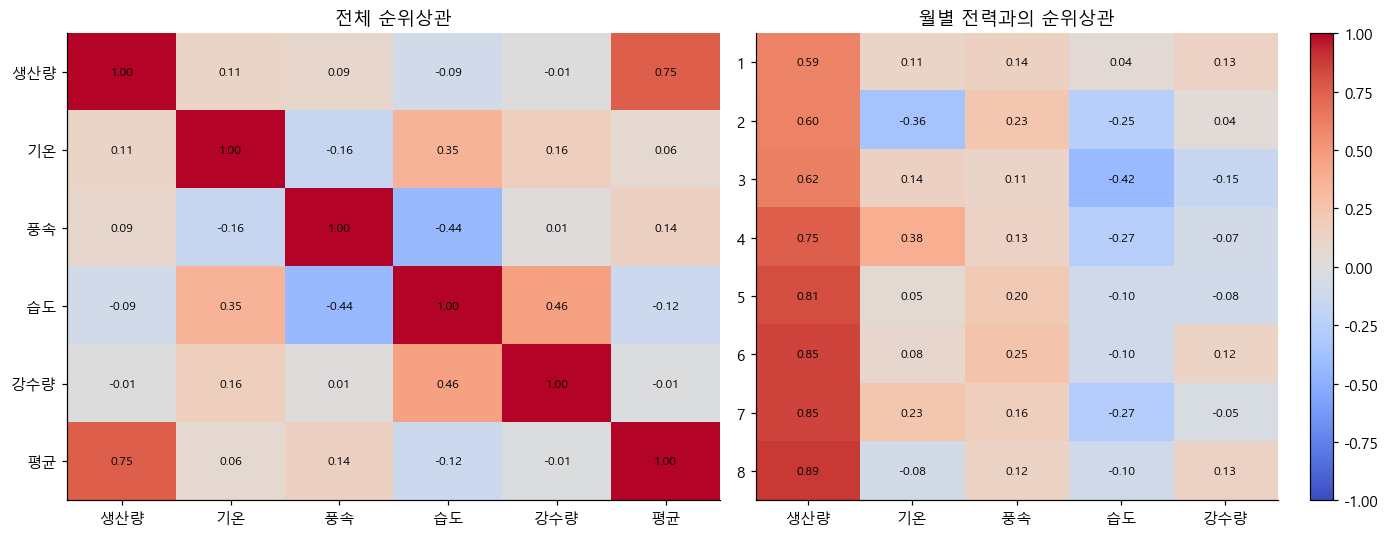

,8월 집단,시간 수,기온·전력 상관
0,전체,744,-0.0758
1,생산 양수,383,0.5988
2,생산 0,361,0.0002


In [10]:
variables=["생산량"]+WEATHER+["평균"]
correlations=data[variables].corr(method="spearman")
monthly=pd.DataFrame({month:g[["생산량"]+WEATHER].corrwith(g["평균"],method="spearman") for month,g in data.groupby("month")}).T
show_table(correlations.reset_index(names="변수"),"09_전체상관")
fig,axes=plt.subplots(1,2,figsize=(13,5))
im=heatmap(axes[0],correlations.to_numpy(),variables,variables,-1,1,fmt=".2f")
heatmap(axes[1],monthly.to_numpy(),monthly.columns,monthly.index,-1,1,fmt=".2f")
axes[0].set_title("전체 순위상관");axes[1].set_title("월별 전력과의 순위상관");fig.colorbar(im,ax=axes[1])
show_figure("09_전체월별관계")
aug=data.loc[data.month.eq(8)]
show_table(pd.DataFrame([{"8월 집단":name,"시간 수":len(g),"기온·전력 상관":g["기온"].corr(g["평균"],method="spearman")}
                        for name,g in [("전체",aug),("생산 양수",aug.loc[aug["생산량"].gt(0)]),("생산 0",aug.loc[aug["생산량"].eq(0)])]]),"09_8월구성")

**결과 해석**

전체 생산량·전력 상관은 0.752이다. 전체 날씨 상관은 작지만 기온은 2월 −0.356, 4월 +0.383으로 방향이 다르다. 8월 전체 −0.076과 생산량 양수 383시간 +0.599의 차이는 기간·생산 구성의 영향을 점검할 근거다. 상관은 인과효과나 예측 성능을 뜻하지 않는다.

## 2.4 평일 전력 분포와 낮은 시간 조합

평일 4,104시간을 모두 포함해 실제 빈 구간과 날짜별 낮은 시각의 정확한 조합을 계산한다.

,형태,날짜 수
0,07시부터 낮은 구간 벗어남,29
1,08시부터 낮은 구간 진입,7
2,하루 내내 낮음,18
3,하루 내내 49 이상,117


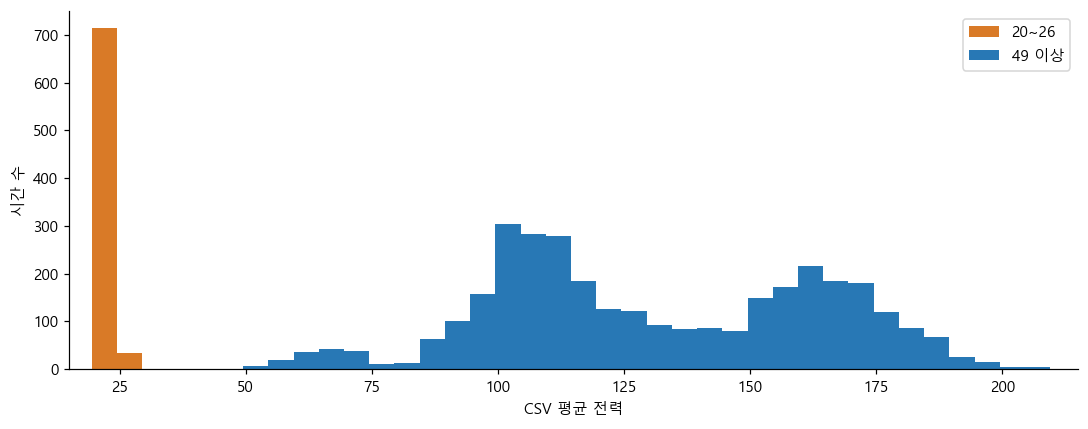

낮은 시간: 747 그중 양수 생산: 92


In [11]:
weekday=data.loc[data.weekend.eq(0)]
unique=np.sort(weekday["평균"].unique());gap=int(np.argmax(np.diff(unique)));cutoff=unique[gap]
assert cutoff==26 and unique[gap+1]==49
patterns=weekday.groupby("date").apply(lambda g:tuple(g.loc[g["평균"].le(cutoff),"시간"]),include_groups=False)
labels={tuple(range(7)):"07시부터 낮은 구간 벗어남",tuple(range(8,24)):"08시부터 낮은 구간 진입",tuple(range(24)):"하루 내내 낮음",():"하루 내내 49 이상"}
pattern_table=pd.DataFrame([{"형태":label,"날짜 수":int(patterns.map(lambda x:x==key).sum())} for key,label in labels.items()])
show_table(pattern_table,"10_평일시간조합")
fig,ax=plt.subplots(figsize=(10,4))
ax.hist([weekday.loc[weekday["평균"].le(cutoff),"평균"],weekday.loc[weekday["평균"].gt(cutoff),"평균"]],
        bins=np.arange(19.5,214.6,5),stacked=True,color=[COLORS[1],COLORS[0]],label=["20~26","49 이상"])
ax.set_xlim(15,215);ax.set_xlabel("CSV 평균 전력");ax.set_ylabel("시간 수");ax.legend();show_figure("10_평일분포")
print("낮은 시간:",int(weekday["평균"].le(cutoff).sum()),"그중 양수 생산:",int((weekday["평균"].le(cutoff)&weekday["생산량"].gt(0)).sum()))

**결과 해석**

평일 747시간(18.20%)은 20~26에 있고 27~48은 비어 있다. 네 시간 조합은 각각 29·7·18·117일이다. 낮은 747시간 중 92시간에는 생산량이 양수다. 이 구간은 관측 분포를 요약한 기술적 기준이며 휴무·설비 정지 판정이 아니다.

## 2.5 시간대별 15분 구간의 전력 패턴

각 구간에서 같은 시간의 반올림 전 평균을 빼고 평일·주말의 시간대별 차이를 평균한다. 높은 값이 나타난 구간 수도 확인한다.

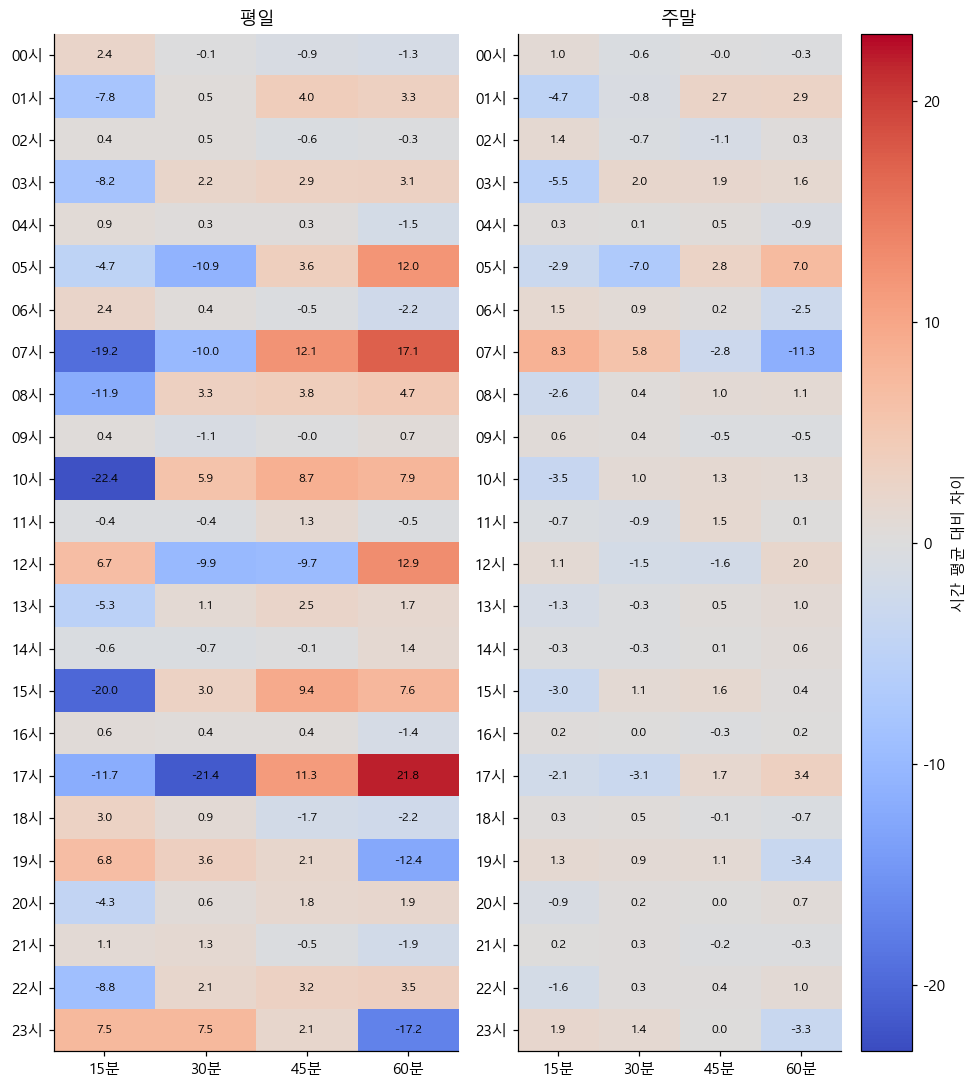

,집단,시간,해당 날짜,전체 날짜
0,평일,7,160,171
1,평일,10,145,171
2,평일,12,129,171
3,평일,17,145,171
4,주말,7,26,70
5,주말,10,13,70
6,주말,12,10,70
7,주말,17,11,70


1월 고정 기준: 185.0


,기준 이상 구간 수,시간 수,비율(%)
0,1,136,37.7778
1,2,114,31.6667
2,3,82,22.7778
3,4,28,7.7778


In [12]:
centered=data[SLOTS].sub(data.level,axis=0)
centered["weekend"]=data.weekend;centered["시간"]=data["시간"]
fig,axes=plt.subplots(1,2,figsize=(9,10))
for group,label in [(0,"평일"),(1,"주말")]:
    matrix=centered.loc[centered.weekend.eq(group)].groupby("시간")[SLOTS].mean()
    im=heatmap(axes[group],matrix.to_numpy(),SLOTS,[f"{h:02}시" for h in matrix.index],-23,23)
    axes[group].set_title(label)
fig.colorbar(im,ax=axes[1],label="시간 평균 대비 차이");show_figure("11_구간별차이")
rows=[]
for group,label in [(0,"평일"),(1,"주말")]:
    for hour in [7,10,12,17]:
        g=data.loc[data.weekend.eq(group)&data["시간"].eq(hour)]
        mask={7:g["60분"]>g["15분"],10:g["15분"]<g[SLOTS[1:]].min(axis=1),
              12:g[["30분","45분"]].max(axis=1)<g[["15분","60분"]].min(axis=1),
              17:g[["45분","60분"]].min(axis=1)>g[["15분","30분"]].max(axis=1)}[hour]
        rows.append({"집단":label,"시간":hour,"해당 날짜":int(mask.sum()),"전체 날짜":len(g)})
show_table(pd.DataFrame(rows),"11_배열조건")
peak_cut=data.loc[data.month.eq(1),"maximum"].quantile(.95)
counts=data[SLOTS].ge(peak_cut).sum(axis=1)
peak_counts=counts[counts.gt(0)].value_counts().sort_index().rename("시간 수").rename_axis("기준 이상 구간 수").reset_index()
peak_counts["비율(%)"]=100*peak_counts["시간 수"]/peak_counts["시간 수"].sum()
print("1월 고정 기준:",peak_cut);show_table(peak_counts,"11_높은구간수")

**결과 해석**

평일 07·10·12·17시에는 구간 위치에 따른 차이가 여러 날짜에서 관측된다. 평일 10시 첫 구간의 평균 대비 차이는 −22.44다. 1월 최대값 95분위수 185를 고정하면 기준 이상 360시간 중 한 구간만 높은 시간은 136개, 네 구간 모두 높은 시간은 28개다. 최대값 하나로 높은 기록의 분포 폭을 모두 설명할 수 없으며 미래 예측 가치는 시간순 검증이 필요하다.

# 3. Analysis

## 연속 시간 비교를 위한 준비

정확히 1·2시간 전의 실제 기록을 연결한다. 순위 관계를 조정할 때 같은 달력 조건의 평균 차이를 먼저 제거하고 과거 생산량·전력 수준을 고려한다. 아래 함수는 이 절에서 반복 사용하는 계산만 정의한다.

In [13]:
def build_pairs():
    data=processed_data.copy()
    assert len(data)==5784 and not data.timestamp.duplicated().any()
    data['level']=data[SLOTS].mean(axis=1)
    data['slot_range']=data[SLOTS].max(axis=1)-data[SLOTS].min(axis=1)
    daily={date:hashlib.sha256(cell[SLOTS].to_numpy(dtype=np.int64).tobytes()).hexdigest()
           for date,cell in data.groupby('date')}
    data['profile']=data.date.map(daily)
    data['month']=data.date.dt.month
    data['weekend']=data.date.dt.dayofweek.ge(5).astype(int)
    data['week']=data.date-pd.to_timedelta(data.date.dt.dayofweek,unit='D')
    old=data.set_index('timestamp').reindex(data.timestamp-pd.Timedelta(hours=1))
    data['past_production']=old['생산량'].to_numpy()
    data['past_level']=old.level.to_numpy()
    data['past_profile']=old.profile.to_numpy()
    part=data.dropna(subset=['past_production','past_level']).copy().reset_index(drop=True)
    part['production_delta']=part['생산량']-part.past_production
    part['power_delta']=part.level-part.past_level
    part['abs_power_delta']=part.power_delta.abs()
    part['change']=np.select([part.production_delta.gt(0),part.production_delta.lt(0)],['increase','decrease'],default='maintain')
    current=part['생산량'].gt(0)
    previous=part.past_production.gt(0)
    part['transition']=np.select([~previous&current,previous&~current,previous&current],
                                ['zero_to_positive','positive_to_zero','positive_to_positive'],default='zero_to_zero')
    # Joint current/previous day profile reflects the boundary used by differences.
    part['pair_profile']=part.past_profile+'|'+part.profile
    counts=part[['date','pair_profile']].drop_duplicates().pair_profile.value_counts()
    part['profile_weight']=1/part.pair_profile.map(counts)
    return data,part

def build_triples():
    data, part = build_pairs()
    index = data.set_index('timestamp')
    previous = index.reindex(part.timestamp - pd.Timedelta(hours=1))
    older = index.reindex(part.timestamp - pd.Timedelta(hours=2))
    part['input_timestamp'] = part.timestamp - pd.Timedelta(hours=1)
    part['older_timestamp'] = part.timestamp - pd.Timedelta(hours=2)
    part['older_level'] = older.level.to_numpy()
    part['target_maximum'] = part[SLOTS].max(axis=1)
    part['target_excess'] = part.target_maximum - part.level
    part['target_relative_excess'] = part.target_excess / part.level.where(part.level.ne(0))
    part['prior_maximum'] = previous[SLOTS].max(axis=1).to_numpy()
    part['prior_last'] = previous[SLOTS[-1]].to_numpy()
    part['prior_first'] = previous[SLOTS[0]].to_numpy()
    part['prior_slot_trend'] = part.prior_last - part.prior_first
    part['prior_last_above_mean'] = part.prior_last - part.past_level
    part['prior_maximum_excess'] = part.prior_maximum - part.past_level
    part['prior_range'] = previous.slot_range.to_numpy()
    part['recent_level_delta'] = part.past_level - part.older_level
    part['known_production_positive'] = part.past_production.gt(0).astype(int)
    part['prior_profile'] = previous.profile.to_numpy()
    part['older_profile'] = older.profile.to_numpy()
    triples = part.loc[part.older_level.notna()].copy().reset_index(drop=True)
    triples['triple_profile'] = triples.older_profile + '|' + triples.prior_profile + '|' + triples.profile
    counts = triples[['date', 'triple_profile']].drop_duplicates().triple_profile.value_counts()
    triples['profile_weight'] = 1 / triples.triple_profile.map(counts)
    assert len(part) == 5781 and len(triples) == 5778
    return data, part, triples

def weighted_corr(x, y, weights):
    x = x - np.average(x, weights=weights)
    y = y - np.average(y, weights=weights)
    denominator = np.sqrt(np.sum(weights*x*x) * np.sum(weights*y*y))
    return float(np.sum(weights*x*y)/denominator) if denominator > 1e-15 else np.nan

def residuals(values, cells, weights, controls=None):
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        values = values[:, None]
    n = cells.max()+1
    sums = np.zeros((n, values.shape[1]))
    np.add.at(sums, cells, weights[:, None]*values)
    mass = np.bincount(cells, weights=weights, minlength=n)
    centered = values - (sums/mass[:, None])[cells]
    if controls is None or not controls.shape[1]:
        return centered
    centered_controls = residuals(controls, cells, weights)
    weighted_controls = centered_controls*np.sqrt(weights[:, None])
    coefficients = np.linalg.lstsq(weighted_controls,
                                   centered*np.sqrt(weights[:, None]), rcond=None)[0]
    return centered-centered_controls@coefficients

def contrast(part,a,b,metric,mode,boot=False):
    sample=part.loc[part.change.isin([a,b])].copy()
    # Only observed matched conditions; no regression or extrapolation.
    cells=sample.groupby(['month','weekend','시간','change']).date.nunique().unstack('change',fill_value=0)
    if a not in cells or b not in cells:
        return None
    support=cells.index[(cells[a]>=2)&(cells[b]>=2)]
    cell_keys=list(zip(sample.month,sample.weekend,sample['시간']))
    support_map={key:i for i,key in enumerate(support)}
    keep=np.array([key in support_map for key in cell_keys])
    sample=sample.loc[keep].copy()
    if sample.empty:
        return None
    cell_ids=np.array([support_map[key] for key,k in zip(cell_keys,keep) if k])
    side=sample.change.eq(b).to_numpy().astype(int)
    slot=cell_ids*2+side
    n_cells=len(support)
    base_w=np.ones(len(sample)) if mode=='date_hour' else sample.profile_weight.to_numpy()
    value=sample[metric].to_numpy()
    # Common calendar composition: pooled eligible-hour weight within each cell.
    fixed_cell_w=np.bincount(cell_ids,weights=base_w,minlength=n_cells)
    def estimate(extra=None):
        w=base_w if extra is None else base_w*extra
        count=np.bincount(slot,weights=w,minlength=n_cells*2).reshape(-1,2)
        total=np.bincount(slot,weights=w*value,minlength=n_cells*2).reshape(-1,2)
        ok=(count>0).all(axis=1)
        if not ok.any():
            return np.nan,np.nan
        means=total[ok]/count[ok]
        averaged=np.average(means,axis=0,weights=fixed_cell_w[ok])
        return float(averaged[0]),float(averaged[1])
    ma,mb=estimate()
    result=dict(a=a,b=b,metric=metric,weighting=mode,matched_cells=n_cells,
        n_a=int((side==0).sum()),n_b=int((side==1).sum()),
        eligible_a=int(part.change.eq(a).sum()),eligible_b=int(part.change.eq(b).sum()),
        days_a=sample.loc[side==0,'date'].nunique(),days_b=sample.loc[side==1,'date'].nunique(),
        adjusted_a=ma,adjusted_b=mb,difference=ma-mb,
        relative_difference=(ma/mb-1) if metric!='power_delta' and mb>0 else np.nan)
    if boot:
        week_id=pd.factorize(sample.week)[0]
        n_weeks=week_id.max()+1
        rng=np.random.default_rng(3103)
        estimates=[]
        for _ in range(800):
            multiplicity=rng.multinomial(n_weeks,np.full(n_weeks,1/n_weeks))
            va,vb=estimate(multiplicity[week_id])
            estimates.append(va-vb)
        result['week_boot_q025'],result['week_boot_q975']=np.nanquantile(estimates,[.025,.975])
        result['bootstrap_finite']=int(np.isfinite(estimates).sum())
    return result

def control_array(sample, include_level=True, degree=3):
    arrays = [sample.known_production_positive.to_numpy()]
    production = rankdata(sample.past_production) / len(sample)
    arrays.extend(production ** power for power in range(1, degree + 1))
    if include_level:
        level = rankdata(sample.past_level) / len(sample)
        arrays.extend(level ** power for power in range(1, degree + 1))
    return np.column_stack(arrays)

analysis_data, pairs, triples = build_triples()
display(pd.DataFrame({"자료":["정상 기록","정확한 1시간 연결","정확한 1·2시간 연결"],"시간 수":[len(analysis_data),len(pairs),len(triples)]}))

,자료,시간 수
0,정상 기록,5784
1,정확한 1시간 연결,5781
2,정확한 1·2시간 연결,5778


## 3.1 생산량 전환과 전력 변화

생산 증감·유지의 구성부터 확인한 뒤 같은 월·시간대·평일/주말에서 생산량 0→양수와 양수 지속을 비교한다. 각 집단에 최소 두 날짜가 있는 조건만 맞춘다.

,change,transition,시간 수
0,decrease,positive_to_positive,1474
1,decrease,positive_to_zero,214
2,increase,positive_to_positive,1582
3,increase,zero_to_positive,215
4,maintain,positive_to_positive,4
5,maintain,zero_to_zero,2292


,metric,weighting,matched_cells,n_a,n_b,adjusted_a,adjusted_b,difference
0,abs_power_delta,date_hour,46,150,567,37.9208,30.2138,7.7070
1,abs_power_delta,profile_balanced,46,150,567,41.5803,32.1086,9.4717
2,target_maximum,date_hour,46,150,567,135.7253,135.3219,0.4035
3,target_maximum,profile_balanced,46,150,567,137.0587,138.0595,-1.0008
4,slot_range,date_hour,46,150,567,22.8978,21.3690,1.5288
5,slot_range,profile_balanced,46,150,567,24.6457,21.9331,2.7126


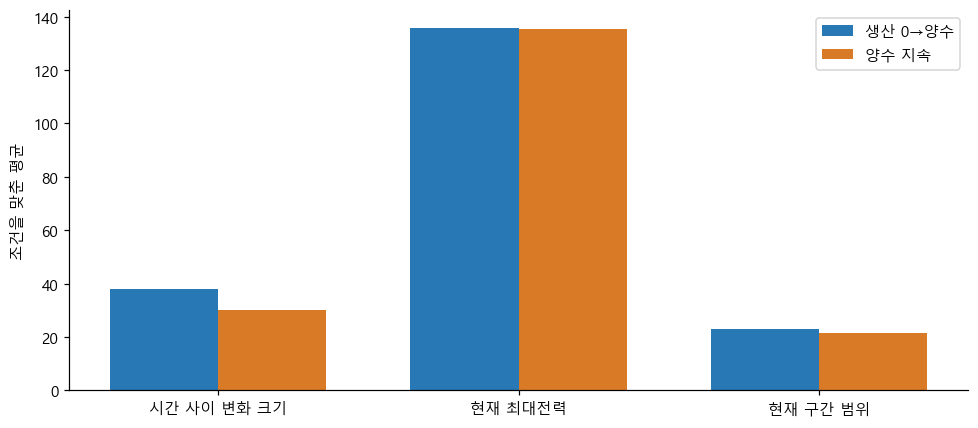

In [14]:
show_table(pairs.groupby(["change","transition"]).size().rename("시간 수").reset_index(),"12_생산전환구성")
transition_pairs=pairs.assign(change=pairs.transition)
comparisons=pd.DataFrame([contrast(transition_pairs,"zero_to_positive","positive_to_positive",metric,mode)
    for metric in ["abs_power_delta","target_maximum","slot_range"] for mode in ["date_hour","profile_balanced"]])
show_table(comparisons[["metric","weighting","matched_cells","n_a","n_b","adjusted_a","adjusted_b","difference"]],"12_달력조건비교")
main=comparisons.loc[comparisons.weighting.eq("date_hour")]
fig,ax=plt.subplots(figsize=(9,4));x=np.arange(len(main))
ax.bar(x-.18,main.adjusted_a,.36,label="생산 0→양수",color=COLORS[0]);ax.bar(x+.18,main.adjusted_b,.36,label="양수 지속",color=COLORS[1])
ax.set_xticks(x,["시간 사이 변화 크기","현재 최대전력","현재 구간 범위"]);ax.set_ylabel("조건을 맞춘 평균");ax.legend();show_figure("12_생산전환비교")

**결과 해석**

생산량 유지 2,296시간 중 2,292시간은 0→0이다. 유지와 증감의 비교를 증감 자체의 영향으로 해석하기 어렵다. 같은 달력 조건에서 0→양수의 전력 변화 크기는 더 컸지만 현재 최대전력은 135.73 대 135.32로 비슷했다. 큰 변화와 높은 최대값은 구분해야 하며 기록상 생산 전환을 실제 설비 재가동으로 해석하지 않는다.

### 전력 구간 전환과 생산량 전환의 차이

전력 20~26·26 초과·20 미만·0을 구분해 전환과 생산량 전환이 얼마나 겹치는지 확인한다. 분류는 관측된 목표값의 사후 분석에만 사용한다.

,previous_state,current_state,시간수,평균변화중앙값,최대변화중앙값
0,0,0,16,0.00,0.0
1,0,양수 20 미만,1,16.50,41.0
2,20~26,0,1,-22.00,-47.0
3,20~26,20~26,1865,0.00,0.0
4,20~26,26 초과,64,39.50,72.0
5,20~26,양수 20 미만,6,-3.50,-5.0
6,26 초과,20~26,64,-47.75,-68.0
7,26 초과,26 초과,3757,-2.00,-2.0
8,양수 20 미만,20~26,7,0.25,0.0


transition,전력 전환,positive_to_positive,positive_to_zero,zero_to_positive,zero_to_zero
0,0→0,0,0,0,16
1,0→양수 20 미만,0,0,0,1
2,20~26→0,0,0,0,1
3,20~26→20~26,74,11,14,1766
4,20~26→26 초과,11,0,5,48
5,20~26→양수 20 미만,0,0,0,6
6,26 초과→20~26,8,35,0,21
7,26 초과→26 초과,2967,168,196,426
8,양수 20 미만→20~26,0,0,0,7


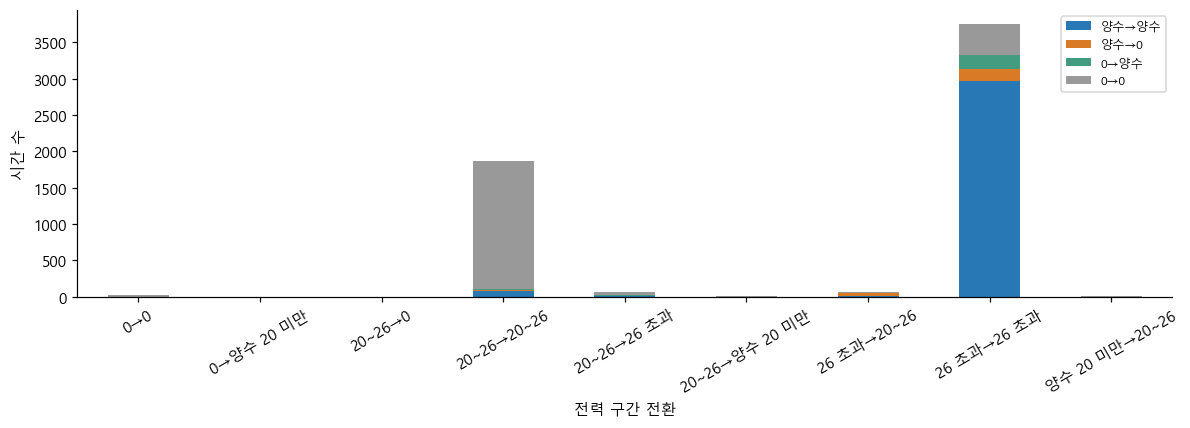

In [15]:
def power_state(v):
    return np.select([v.eq(0),v.between(20,26),v.gt(26)],["0","20~26","26 초과"],default="양수 20 미만")
pairs["previous_state"]=power_state(np.floor(pairs.past_level+.5))
pairs["current_state"]=power_state(pairs["평균"])
prior_max=data.set_index("timestamp").maximum.reindex(pairs.timestamp-pd.Timedelta(hours=1)).to_numpy()
pairs["maximum_delta"]=pairs.target_maximum-prior_max
state_summary=pairs.groupby(["previous_state","current_state"]).agg(시간수=("timestamp","size"),평균변화중앙값=("power_delta","median"),최대변화중앙값=("maximum_delta","median")).reset_index()
show_table(state_summary,"13_전력전환")
overlap=pd.crosstab(pairs.previous_state+"→"+pairs.current_state,pairs.transition)
show_table(overlap.reset_index(names="전력 전환"),"13_생산전환겹침")
fig,ax=plt.subplots(figsize=(11,4))
overlap.rename(columns={"positive_to_positive":"양수→양수","positive_to_zero":"양수→0","zero_to_positive":"0→양수","zero_to_zero":"0→0"}).plot.bar(stacked=True,ax=ax,color=[COLORS[0],COLORS[1],COLORS[2],"#999999"])
ax.set_ylabel("시간 수");ax.set_xlabel("전력 구간 전환");ax.tick_params(axis="x",rotation=30);ax.legend(fontsize=8);show_figure("13_전환겹침")

**결과 해석**

20~26→26 초과 상승 64시간 중 생산량 0→양수는 5시간뿐이다. 반대 하락 64시간 중 생산량 양수→0은 35시간이다. 두 전환은 일치하지 않는다. 26 초과가 이어진 시간에도 큰 상승·하락이 있어 생산 전환이나 낮은 구간 출입만으로 전체 전력 변동을 대신할 수 없다.

## 3.2 과거 전력으로 생산량 전환을 사전 구분

직전 생산량 0인 기록에서 다음 양수 전환을 분류한다. 1~4월 학습·5~6월 검증에서 정한 HGB 설정과 경계를 고정하고 7~8월을 평가한다.

,입력,시간 수,실제 전환,TP,FP,FN,정밀도,재현율,AP,고정 경계
0,달력,617,52,35,51,17,0.4070,0.6731,0.3767,0.3242
1,달력+직전 평균,617,52,50,25,2,0.6667,0.9615,0.9024,0.2354
2,달력+평균+구간 변화,617,52,50,25,2,0.6667,0.9615,0.9043,0.2581


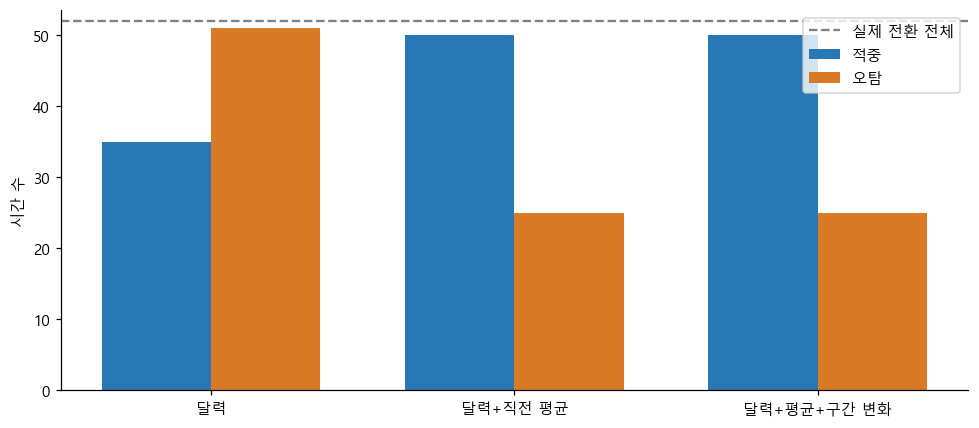

In [16]:
def transition_matrix(frame,features):
    # Fixed calendar categories, no fitted target-derived transformations.
    hours=np.eye(24)[frame['시간'].to_numpy(dtype=int)]
    return np.column_stack([hours,frame.weekend,frame.month]+[frame[f] for f in features])


feature_sets={"달력":[],"달력+직전 평균":["past_level"],"달력+평균+구간 변화":["past_level","prior_slot_trend"]}
fixed_cuts=[.32418130623928276,.23541496682336432,.2580651743247188]
risk=triples.loc[triples.past_production.eq(0)].copy()
risk["event"]=risk.transition.eq("zero_to_positive").astype(int)
train=risk.loc[risk.month.le(6)];test_transition=risk.loc[risk.month.ge(7)]
rows=[]
for (name,features_transition),cut in zip(feature_sets.items(),fixed_cuts):
    transition_clf=HistGradientBoostingClassifier(max_iter=150,max_leaf_nodes=7,min_samples_leaf=20,l2_regularization=1,learning_rate=.05,early_stopping=False,random_state=3203)
    transition_clf.fit(transition_matrix(train,features_transition),train.event)
    prob=transition_clf.predict_proba(transition_matrix(test_transition,features_transition))[:,1]
    y=test_transition.event.to_numpy();alarm_transition=prob>=cut
    tp=int(((y==1)&alarm_transition).sum());fp=int(((y==0)&alarm_transition).sum())
    rows.append({"입력":name,"시간 수":len(y),"실제 전환":int(y.sum()),"TP":tp,"FP":fp,"FN":int(y.sum())-tp,
                 "정밀도":tp/(tp+fp),"재현율":tp/y.sum(),"AP":average_precision_score(y,prob),"고정 경계":cut})
transition_results=pd.DataFrame(rows);show_table(transition_results,"14_생산전환사전구분")
fig,ax=plt.subplots(figsize=(9,4));x=np.arange(3)
ax.bar(x-.18,transition_results.TP,.36,label="적중",color=COLORS[0]);ax.bar(x+.18,transition_results.FP,.36,label="오탐",color=COLORS[1])
ax.axhline(test_transition.event.sum(),ls="--",color="gray",label="실제 전환 전체")
ax.set_xticks(x,transition_results["입력"]);ax.set_ylabel("시간 수");ax.legend();show_figure("14_생산전환탐지")

**결과 해석**

617시간 중 실제 전환은 52시간이다. 달력만 사용할 때 TP 35·FP 51에서 직전 평균 추가 시 TP 50·FP 25로 개선된다. 구간 변화 추가는 적중·오탐 수가 같아 큰 추가 이득은 확인되지 않는다. 이는 생산 전환의 정보 가치 검토이며 다음 시간 전력값의 예측 성능과는 구분한다.

## 3.3 날씨 관계를 조건 안에서 검토

네 기상변수가 모두 있는 평일의 동일 기록에서 단순 순위상관과 달력·생산·다른 기상정보를 고려한 잔여 관계를 비교한다.

,variable,adjustment,weighting,n,days,correlation
0,기온,raw,date_hour,4102,171,0.2265
1,기온,joint,date_hour,4102,171,-0.0043
2,풍속,raw,date_hour,4102,171,0.1946
3,풍속,joint,date_hour,4102,171,0.0455
4,습도,raw,date_hour,4102,171,-0.1024
5,습도,joint,date_hour,4102,171,0.0999
6,강수량,raw,date_hour,4102,171,0.0573
7,강수량,joint,date_hour,4102,171,-0.0604


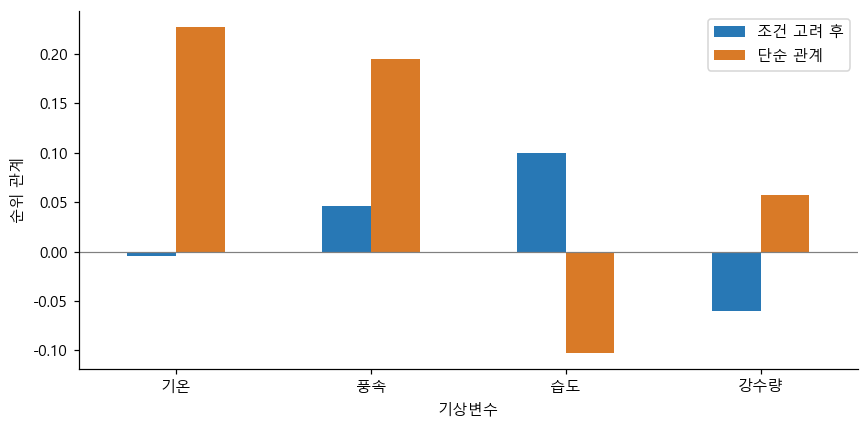

,비교,n,days,correlation
0,8월 양수 생산 평일,360,17,0.3022
1,동일 날짜 차이까지 고려,360,17,0.0136


In [17]:
def weather_association(sample,feature,adjustment,mode):
    needed=[feature,'level','생산량']+ (WEATHER if adjustment=='joint' else [])
    sample=sample.dropna(subset=list(dict.fromkeys(needed))).copy()
    keys=['month','weekend','시간']
    if adjustment!='raw':
        counts=sample.groupby(keys).date.transform('nunique')
        sample=sample.loc[counts.ge(3)].copy()
    if len(sample)<10:
        return None
    w=np.ones(len(sample)) if mode=='date_hour' else sample.profile_weight.to_numpy()
    x=rankdata(sample[feature])/len(sample); y=rankdata(sample.level)/len(sample)
    if adjustment=='raw':
        value=weighted_corr(x,y,w)
    else:
        cell=pd.factorize(pd.MultiIndex.from_frame(sample[keys]))[0]
        controls=None
        if adjustment in ('production','joint'):
            rankprod=rankdata(sample['생산량'])/len(sample)
            controls=np.column_stack([sample.production_positive,rankprod,rankprod**2,rankprod**3])
        if adjustment=='joint':
            other=[rankdata(sample[c])/len(sample) for c in WEATHER if c!=feature]
            controls=np.column_stack([controls]+other)
        res=residuals(np.column_stack([x,y]),cell,w,controls)
        value=weighted_corr(res[:,0],res[:,1],w)
    return dict(variable=feature,adjustment=adjustment,weighting=mode,n=len(sample),
        days=sample.date.nunique(),correlation=value)

def temperature_adjusted(sample,date_control=False,prod_form='cubic',other_weather=True):
    sample=sample.dropna(subset=WEATHER).copy()
    counts=sample.groupby(['month','weekend','시간']).date.transform('nunique')
    sample=sample.loc[counts.ge(3)]
    cells=pd.factorize(pd.MultiIndex.from_frame(sample[['month','weekend','시간']]))[0]
    p=rankdata(sample['생산량'])/len(sample)
    controls=np.column_stack([sample.production_positive,p])
    if prod_form=='cubic':
        controls=np.column_stack([controls,p**2,p**3])
    if other_weather:
        controls=np.column_stack([controls]+[rankdata(sample[c])/len(sample) for c in WEATHER if c!='기온'])
    if date_control:
        date_ids=pd.factorize(sample.date)[0]
        # Date-level nuisance controls identify within-date contrasts, not the
        # same estimand as across-date thermal/weather load association.
        controls=np.column_stack([controls,np.eye(date_ids.max()+1)[date_ids]])
    values=np.column_stack([rankdata(sample['기온']),rankdata(sample.level)])/len(sample)
    w=np.ones(len(sample))
    res=residuals(values,cells,w,controls)
    return dict(n=len(sample),days=sample.date.nunique(),correlation=weighted_corr(res[:,0],res[:,1],w))


weather_data=data.assign(production_positive=data["생산량"].gt(0).astype(int))
common_weather=weather_data.loc[weather_data.weekend.eq(0)].dropna(subset=WEATHER)
common_weather=common_weather.loc[common_weather.groupby(KEYS).date.transform("nunique").ge(3)]
weather_results=pd.DataFrame([weather_association(common_weather,f,adjustment,"date_hour") for f in WEATHER for adjustment in ["raw","joint"]])
show_table(weather_results,"15_동일행날씨관계")
chart=weather_results.pivot(index="variable",columns="adjustment",values="correlation").reindex(WEATHER)
fig,ax=plt.subplots(figsize=(8,4));chart.rename(columns={"raw":"단순 관계","joint":"조건 고려 후"}).plot.bar(ax=ax,color=COLORS[:2])
ax.legend(title="");ax.set_xlabel("기상변수");ax.axhline(0,color="gray",lw=.8);ax.set_ylabel("순위 관계");ax.tick_params(axis="x",rotation=0);show_figure("15_날씨관계조정")
aug_positive=weather_data.loc[weather_data.weekend.eq(0)&weather_data.month.eq(8)&weather_data.production_positive.eq(1)]
show_table(pd.DataFrame([{"비교":label,**temperature_adjusted(aug_positive,date_control=control)} for label,control in [("8월 양수 생산 평일",False),("동일 날짜 차이까지 고려",True)]]),"15_8월날짜조정")

**결과 해석**

동일한 평일 4,102시간에서 조건을 고려한 관계는 기온 −0.004·풍속 +0.046·습도 +0.100·강수량 −0.060으로 약하다. 8월 양수 생산 평일의 기온 관계도 날짜 차이를 고려하면 +0.302에서 +0.014로 약해진다. 날씨의 예측 가치를 단정하지 않고 관측을 마친 과거 기상 입력의 실제 오차 효과로 판단한다.

## 3.4 다음 최대전력과 마지막 15분 값

직전 평균·생산·달력을 고려한 네 구간의 부분 순위 관계를 비교하고, 직전 최대값까지 조정한 관계와 엄격한 동일 평균 비교의 예외를 확인한다.

,feature,target,n,days,correlation
0,prior_first,target_maximum,5778,241,0.0300
3,prior_second,target_maximum,5778,241,-0.1267
6,prior_third,target_maximum,5778,241,0.0300
9,prior_last,target_maximum,5778,241,0.4338


,기간,feature,adjustment,weighting,n,days,cells,correlation
0,전체,prior_last,mean_maximum,date_hour,5778,241,384,0.4093
1,전체,prior_last,exact_mean,date_hour,1039,141,245,0.2356
2,1~4월,prior_last,mean_maximum,date_hour,2878,120,192,0.3942
3,1~4월,prior_last,exact_mean,date_hour,900,73,200,-0.0091
4,5~6월,prior_last,mean_maximum,date_hour,1464,61,96,0.4297
5,5~6월,prior_last,exact_mean,date_hour,53,25,17,0.3166
6,7~8월,prior_last,mean_maximum,date_hour,1436,60,96,0.3901
7,7~8월,prior_last,exact_mean,date_hour,86,43,28,0.3804


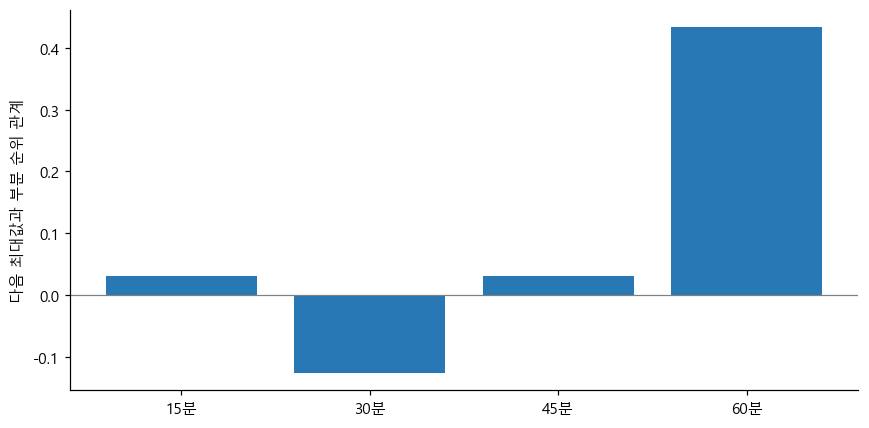

In [18]:
def terminal_compare(sample, mode='date_hour', adjustment='mean_maximum'):
    keys = KEYS if adjustment != 'exact_mean' else KEYS + ['past_level', 'known_production_positive']
    sample = sample.loc[sample.groupby(keys).date.transform('nunique').ge(3)].copy()
    if sample.empty:
        return []
    weights = np.ones(len(sample)) if mode == 'date_hour' else sample.profile_weight.to_numpy()
    values = np.column_stack([rankdata(sample[key]) / len(sample) for key in TERMINAL_FEATURES + ['target_maximum']])
    cells = pd.factorize(pd.MultiIndex.from_frame(sample[keys]))[0]
    controls = control_array(sample, include_level=adjustment != 'exact_mean')
    if adjustment in ['mean_maximum', 'mean_maximum_trend']:
        maximum = rankdata(sample.prior_maximum) / len(sample)
        controls = np.column_stack([controls, maximum, maximum ** 2, maximum ** 3])
    if adjustment == 'mean_maximum_trend':
        controls = np.column_stack([controls, rankdata(sample.prior_slot_trend) / len(sample)])
    res = residuals(values, cells, weights, controls)
    return [dict(feature=feature, adjustment=adjustment, weighting=mode, n=len(sample),
                 days=sample.date.nunique(), cells=int(cells.max() + 1),
                 correlation=weighted_corr(res[:, i], res[:, -1], weights))
            for i, feature in enumerate(TERMINAL_FEATURES)
            if not (adjustment == 'mean_maximum_trend' and feature == 'prior_slot_trend')]

def slot_group_associations(sample, mode='date_hour', degree=3, add_dates=False):
    sample = sample.loc[sample.groupby(KEYS).date.transform('nunique').ge(3)].copy()
    weights = np.ones(len(sample)) if mode == 'date_hour' else sample.profile_weight.to_numpy()
    features = ['prior_first', 'prior_second', 'prior_third', 'prior_last',
                'prior_slot_trend', 'prior_last_above_mean']
    targets = ['target_maximum', 'level', 'target_excess']
    values = np.column_stack([rankdata(sample[column]) / len(sample) for column in features + targets])
    controls = control_array(sample, degree=degree)
    if add_dates:
        dates = pd.factorize(sample.date)[0]
        controls = np.column_stack([controls, np.eye(dates.max() + 1)[dates]])
    cells = pd.factorize(pd.MultiIndex.from_frame(sample[KEYS]))[0]
    result = residuals(values, cells, weights, controls)
    rows = []
    for i, feature in enumerate(features):
        for j, target in enumerate(targets):
            rows.append(dict(feature=feature, target=target, n=len(sample), days=sample.date.nunique(),
                             correlation=weighted_corr(result[:, i], result[:, len(features) + j], weights)))
    return rows


TERMINAL_FEATURES=["prior_last","prior_slot_trend","prior_last_above_mean","prior_maximum_excess"]
previous=data.set_index("timestamp").reindex(triples.timestamp-pd.Timedelta(hours=1))
triples["prior_second"]=previous["30분"].to_numpy();triples["prior_third"]=previous["45분"].to_numpy()
slot_results=pd.DataFrame(slot_group_associations(triples))
slot_max=slot_results.loc[slot_results.target.eq("target_maximum")&slot_results.feature.isin(["prior_first","prior_second","prior_third","prior_last"])]
show_table(slot_max,"16_직전구간관계")
unique_rows=[]
for period,g in [("전체",triples),("1~4월",triples.loc[triples.month.le(4)]),("5~6월",triples.loc[triples.month.between(5,6)]),("7~8월",triples.loc[triples.month.ge(7)])]:
    for adjustment in ["mean_maximum","exact_mean"]:
        unique_rows += [{"기간":period,**r} for r in terminal_compare(g,adjustment=adjustment) if r["feature"]=="prior_last"]
terminal_results=pd.DataFrame(unique_rows);show_table(terminal_results,"16_마지막값민감도")
fig,ax=plt.subplots(figsize=(8,4));ax.bar(["15분","30분","45분","60분"],slot_max.correlation,color=COLORS[0])
ax.axhline(0,color="gray",lw=.8);ax.set_ylabel("다음 최대값과 부분 순위 관계");show_figure("16_직전네구간")

**결과 해석**

마지막 값의 관계는 +0.434로 가장 크고 직전 최대값까지 고려해도 +0.409다. 기간별로 양의 방향이 유지된다. 그러나 정확히 같은 과거 평균을 맞춘 비교는 1,039시간만 남으며 초기 관계는 −0.009다. 모든 조건의 동일한 효과로 일반화하지 않는다. 실제 예측 이득은 다음 Modeling의 시간순 오차 비교로 판단한다.

# 4. Modeling

## 4.1 시간순 평가와 기본 모델 선택

다음 한 시간의 네 구간 중 최대값을 목표로 사용한다. 달력은 목표 시간 정보, 생산·전력은 직전 관측까지의 정보다. 정확한 1·2·24·168시간 시차가 있는 공통 행으로 비교한다. 당시 과거 내부 검증에서 선택한 설정을 고정해 4·5·6월을 재학습·예측하며, Optuna 전체 탐색은 재실행하지 않는다.

In [19]:
FEATURE_CONTRACT = {'period': [20210101, 20210831],
 'valid_hour': [0, 23],
 'lags_hours': [1, 2, 24, 168],
 'pools': {'core': [1, 2], 'common': [1, 2, 24, 168]}}

def profile(values):
    # Stable across numpy byte order and independently reproducible with csv.
    return hashlib.sha256(",".join(format(float(v), ".17g") for v in values).encode()).hexdigest()

def build_model_frame(contract=None):
    c = contract or FEATURE_CONTRACT
    raw = raw_data.copy()
    scoped = raw.loc[raw["날짜"].between(*c["period"])].copy()
    invalid = scoped.loc[~scoped["시간"].between(*c["valid_hour"])].copy()
    valid = processed_data.copy()
    valid["timestamp"] = pd.to_datetime(valid["날짜"].astype(str), format="%Y%m%d") + pd.to_timedelta(valid["시간"], unit="h")
    valid = valid.sort_values("timestamp").reset_index(drop=True)
    assert not valid.timestamp.duplicated().any()
    assert valid.groupby("날짜")["시간"].apply(lambda s: set(s) == set(range(24))).all()
    assert valid[SLOTS + ["생산량"]].notna().all().all()
    f = pd.DataFrame({"timestamp": valid.timestamp})
    f["date"] = f.timestamp.dt.normalize()
    f["target_maximum"] = valid[SLOTS].max(axis=1)
    f["target_mean"] = valid[SLOTS].mean(axis=1)
    f["diag_target_production"] = valid["생산량"]
    f["diag_target_rounded_mean"] = valid["평균"]
    f["month"] = f.timestamp.dt.month
    f["weekend"] = (f.timestamp.dt.dayofweek >= 5).astype(int)
    f["hour_sin"] = np.sin(2 * np.pi * f.timestamp.dt.hour / 24)
    f["hour_cos"] = np.cos(2 * np.pi * f.timestamp.dt.hour / 24)
    for dow in range(7):
        f[f"dow_{dow}"] = (f.timestamp.dt.dayofweek == dow).astype(int)
    valid["mean"] = f.target_mean
    valid["maximum"] = f.target_maximum
    valid["last"] = valid[SLOTS[-1]]
    index = valid.set_index("timestamp")
    for lag in c["lags_hours"]:
        times = f.timestamp - pd.Timedelta(hours=lag)
        prior = index.reindex(pd.DatetimeIndex(times))
        f[f"lag{lag}_timestamp"] = times.where(times.isin(index.index))
        f[f"available_lag{lag}"] = times.isin(index.index)
        for metric in ("mean", "maximum", "last"):
            f[f"lag{lag}_{metric}"] = prior[metric].to_numpy()
        f[f"lag{lag}_production"] = prior["생산량"].to_numpy()
    f["lag1_production_zero"] = (f.lag1_production == 0).astype(float).where(f.available_lag1)
    for name, source_col in WEATHER_MAP.items():
        f[f"lag1_{name}"] = index.reindex(pd.DatetimeIndex(f.timestamp - pd.Timedelta(hours=1)))[source_col].to_numpy()
    for pool, lags in c["pools"].items():
        f[f"eligible_{pool}"] = f[[f"available_lag{lag}" for lag in lags]].all(axis=1)
    daily = {date: profile(cell[SLOTS].to_numpy().reshape(-1)) for date, cell in valid.groupby("날짜")}
    f["diag_target_profile"] = valid["날짜"].map(daily)
    previous_positive = f.lag1_production > 0
    current_positive = f.diag_target_production > 0
    f["diag_production_transition"] = np.select(
        [~f.available_lag1, ~previous_positive & current_positive,
         previous_positive & ~current_positive, previous_positive & current_positive],
        ["unavailable", "zero_to_positive", "positive_to_zero", "positive_to_positive"],
        default="zero_to_zero")
    return raw, invalid, valid, f

def make_model(family, params):
    if family == "HGB":
        return HistGradientBoostingRegressor(**params, early_stopping=False, random_state=42)
    if family == "XGBoost":
        return XGBRegressor(**params, objective="reg:squarederror", tree_method="hist", random_state=42, n_jobs=4)
    if family == "LightGBM":
        return LGBMRegressor(**params, objective="regression", subsample_freq=1, random_state=42, n_jobs=4,
                             deterministic=True, force_col_wise=True, verbosity=-1)
    if family == "CatBoost":
        return CatBoostRegressor(**params, loss_function="RMSE", random_seed=42, thread_count=4,
                                 verbose=False, allow_writing_files=False, task_type="CPU")
    if family == "ExtraTrees":
        return ExtraTreesRegressor(**params, random_state=42, n_jobs=4, bootstrap=False)
    raise ValueError(family)

_, _, _, model_frame = build_model_frame()
# 당시 중간 CSV의 숫자 읽기 경계를 재현해 트리의 경계 비교를 일치시킨다.
feature_csv=model_frame.to_csv(index=False)
development_frame=pd.read_csv(io.StringIO(feature_csv),float_precision="round_trip",parse_dates=["timestamp","date"])
model_frame=pd.read_csv(io.StringIO(feature_csv),parse_dates=["timestamp"])
model_frame["date"]=pd.to_datetime(model_frame["date"])
display(pd.DataFrame({"자료":["시차 1·2", "시차 1·2·24·168"],"시간 수":[int(model_frame.eligible_core.sum()),int(model_frame.eligible_common.sum())]}))

,자료,시간 수
0,시차 1·2,5778
1,시차 1·2·24·168,5520


### 모델별 재학습과 개발 평가

각 평가 월 이전 자료에서만 학습한다. HGB·XGBoost·LightGBM·CatBoost·ExtraTrees와 고정 앙상블을 동일한 행에서 비교한다. 아래 표·그림은 이번 실행에서 생성한 예측의 지표다. 초기 Ridge·Elastic Net·SVR도 당시 고정 설정으로 같은 시차 자료에서 다시 학습한다.

,모델,전체 MAE,일별 최대 시간 MAE,평가 시간
4,HGB_initial,6.7380,11.7506,2184
2,ExtraTrees,6.8252,11.5400,2184
13,weighted_top3,6.8718,13.0355,2184
9,mean5,6.9050,14.0914,2184
3,HGB,6.9626,13.2506,2184
8,XGBoost,7.1313,12.8641,2184
0,CatBoost,7.4801,17.7944,2184
5,LightGBM,7.4936,15.7558,2184
11,previous_hour,13.7930,36.5890,2184
7,SVR_initial,14.2596,31.9998,2184


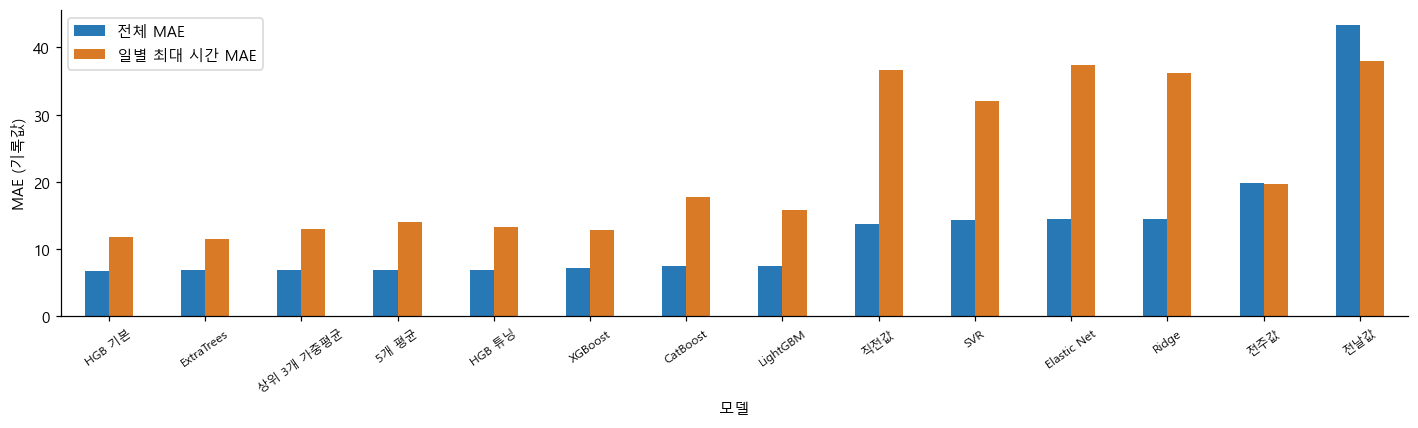

In [20]:
SELECTED_CONFIGS = [
    {'split': 'dev_apr', 'model': 'HGB', 'parameters': {'learning_rate': 0.030629453917788534, 'max_iter': 100, 'max_leaf_nodes': 31, 'min_samples_leaf': 24, 'l2_regularization': 0.07460699686208686}},
    {'split': 'dev_apr', 'model': 'XGBoost', 'parameters': {'learning_rate': 0.06218141172498477, 'n_estimators': 100, 'max_depth': 5, 'min_child_weight': 1.3551239377519961, 'subsample': 0.9518992098644288, 'colsample_bytree': 0.8475647936326245, 'reg_alpha': 0.11794169248505552, 'reg_lambda': 10.28813800307215}},
    {'split': 'dev_apr', 'model': 'LightGBM', 'parameters': {'learning_rate': 0.06514382276594655, 'n_estimators': 100, 'num_leaves': 31, 'min_child_samples': 77, 'subsample': 0.8507593653024389, 'colsample_bytree': 0.7843204658576869, 'reg_alpha': 3.235444438857017, 'reg_lambda': 3.6042369944981556}},
    {'split': 'dev_apr', 'model': 'CatBoost', 'parameters': {'learning_rate': 0.020077656915648476, 'iterations': 350, 'depth': 3, 'l2_leaf_reg': 18.693711815288413, 'random_strength': 0.3941437038625003}},
    {'split': 'dev_apr', 'model': 'ExtraTrees', 'parameters': {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 8, 'max_features': 0.9091346613258848}},
    {'split': 'dev_apr', 'model': 'mean5', 'members': ['HGB', 'XGBoost', 'LightGBM', 'CatBoost', 'ExtraTrees'], 'weights': [0.2, 0.2, 0.2, 0.2, 0.2]},
    {'split': 'dev_apr', 'model': 'weighted_top3', 'members': ['ExtraTrees', 'XGBoost', 'CatBoost'], 'weights': [0.40532708527343303, 0.40749140979791787, 0.18718150492864916]},
    {'split': 'dev_may', 'model': 'HGB', 'parameters': {'learning_rate': 0.02649083634077794, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 24, 'l2_regularization': 0.16283124535115095}},
    {'split': 'dev_may', 'model': 'XGBoost', 'parameters': {'learning_rate': 0.06017761665213941, 'n_estimators': 150, 'max_depth': 6, 'min_child_weight': 13.962563737015762, 'subsample': 0.9818496824692567, 'colsample_bytree': 0.9684482051282947, 'reg_alpha': 0.0644932207737863, 'reg_lambda': 13.220877067405619}},
    {'split': 'dev_may', 'model': 'LightGBM', 'parameters': {'learning_rate': 0.028426000618809066, 'n_estimators': 150, 'num_leaves': 31, 'min_child_samples': 18, 'subsample': 0.8038370481489951, 'colsample_bytree': 0.8283459080269155, 'reg_alpha': 0.1656786900722462, 'reg_lambda': 0.9605220063255229}},
    {'split': 'dev_may', 'model': 'CatBoost', 'parameters': {'learning_rate': 0.06116380695944907, 'iterations': 150, 'depth': 5, 'l2_leaf_reg': 6.373804226251141, 'random_strength': 0.13517644862202438}},
    {'split': 'dev_may', 'model': 'ExtraTrees', 'parameters': {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 8, 'max_features': 0.901858643908981}},
    {'split': 'dev_may', 'model': 'mean5', 'members': ['HGB', 'XGBoost', 'LightGBM', 'CatBoost', 'ExtraTrees'], 'weights': [0.2, 0.2, 0.2, 0.2, 0.2]},
    {'split': 'dev_may', 'model': 'weighted_top3', 'members': ['ExtraTrees', 'XGBoost', 'CatBoost'], 'weights': [0.5304100073470729, 0.4535074664867448, 0.016082526166182345]},
    {'split': 'dev_jun', 'model': 'HGB', 'parameters': {'learning_rate': 0.02649083634077794, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 24, 'l2_regularization': 0.16283124535115095}},
    {'split': 'dev_jun', 'model': 'XGBoost', 'parameters': {'learning_rate': 0.06017761665213941, 'n_estimators': 150, 'max_depth': 6, 'min_child_weight': 13.962563737015762, 'subsample': 0.9818496824692567, 'colsample_bytree': 0.9684482051282947, 'reg_alpha': 0.0644932207737863, 'reg_lambda': 13.220877067405619}},
    {'split': 'dev_jun', 'model': 'LightGBM', 'parameters': {'learning_rate': 0.06694878049501037, 'n_estimators': 100, 'num_leaves': 31, 'min_child_samples': 17, 'subsample': 0.9522781242028121, 'colsample_bytree': 0.7609524784084656, 'reg_alpha': 0.0005313867388561592, 'reg_lambda': 8.553440248964774}},
    {'split': 'dev_jun', 'model': 'CatBoost', 'parameters': {'learning_rate': 0.03244664696834518, 'iterations': 450, 'depth': 7, 'l2_leaf_reg': 13.133027133784852, 'random_strength': 0.13962255767463425}},
    {'split': 'dev_jun', 'model': 'ExtraTrees', 'parameters': {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 8, 'max_features': 0.8865973728386163}},
    {'split': 'dev_jun', 'model': 'mean5', 'members': ['HGB', 'XGBoost', 'LightGBM', 'CatBoost', 'ExtraTrees'], 'weights': [0.2, 0.2, 0.2, 0.2, 0.2]},
    {'split': 'dev_jun', 'model': 'weighted_top3', 'members': ['ExtraTrees', 'XGBoost', 'LightGBM'], 'weights': [0.5771085900862373, 0.41472770966406086, 0.00816370024970193]}
]

def metrics(g):
    if not len(g):
        return {"hours": 0, **{n: None for n in ["mae", "rmse", "bias", "under", "over"]}}
    err = g.prediction.to_numpy() - g.actual.to_numpy()
    return {"hours": len(g), "mae": float(np.mean(abs(err))), "rmse": float(np.sqrt(np.mean(err ** 2))),
            "bias": float(np.mean(err)), "under": float(np.mean(np.maximum(-err, 0))), "over": float(np.mean(np.maximum(err, 0)))}


basic_features=["hour_sin","hour_cos","month","weekend"]+[f"dow_{i}" for i in range(7)]+["lag1_production","lag1_production_zero","lag1_mean","lag1_maximum","lag2_mean","lag2_maximum"]
common_frame=development_frame.loc[development_frame.eligible_common].copy()
development_parts=[]
for month,split in [(4,"dev_apr"),(5,"dev_may"),(6,"dev_jun")]:
    start=pd.Timestamp(2021,month,1)
    train_dev=common_frame.loc[common_frame.timestamp.lt(start)]
    valid_dev=common_frame.loc[common_frame.month.eq(month)]
    dev_predictions={"previous_hour":valid_dev.lag1_maximum.to_numpy(),"previous_day":valid_dev.lag24_maximum.to_numpy(),"previous_week":valid_dev.lag168_maximum.to_numpy()}
    initial_models={
        "Ridge_initial":make_pipeline(StandardScaler(),Ridge(alpha=10.)),
        "ElasticNet_initial":TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),ElasticNet(alpha=.01,l1_ratio=.5,max_iter=20000,tol=.0001,selection="cyclic")),transformer=StandardScaler()),
        "SVR_initial":TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),SVR(C=1.,gamma=.03,epsilon=.05,kernel="rbf",cache_size=512)),transformer=StandardScaler()),
        "HGB_initial":HistGradientBoostingRegressor(max_leaf_nodes=15,max_iter=150,learning_rate=.05,min_samples_leaf=20,l2_regularization=1.,early_stopping=False,random_state=42)}
    for name,initial_model in initial_models.items():
        initial_model.fit(train_dev[basic_features],train_dev.target_maximum)
        dev_predictions[name]=initial_model.predict(valid_dev[basic_features])
    for item in [c for c in SELECTED_CONFIGS if c["split"]==split and "parameters" in c]:
        fitted=make_model(item["model"],item["parameters"])
        fitted.fit(train_dev[basic_features],train_dev.target_maximum)
        dev_predictions[item["model"]]=fitted.predict(valid_dev[basic_features])
    for item in [c for c in SELECTED_CONFIGS if c["split"]==split and "members" in c]:
        dev_predictions[item["model"]]=np.column_stack([dev_predictions[n] for n in item["members"]])@np.asarray(item["weights"])
    for name,values in dev_predictions.items():
        p=valid_dev[["timestamp","date","month"]].copy();p["model"]=name;p["actual"]=valid_dev.target_maximum;p["prediction"]=values
        development_parts.append(p)
development_predictions=pd.concat(development_parts,ignore_index=True)
development_summary=[]
for name,g in development_predictions.groupby("model"):
    daily_errors=[]
    for date,day in g.groupby("date"):
        if len(day)==24:
            peak=day.loc[day.actual.eq(day.actual.max())];daily_errors.append(metrics(peak)["mae"])
    development_summary.append({"모델":name,"전체 MAE":metrics(g)["mae"],"일별 최대 시간 MAE":np.mean(daily_errors),"평가 시간":len(g)})
development_summary=pd.DataFrame(development_summary).sort_values("전체 MAE")
show_table(development_summary,"17_시간순모델비교")
plot_models=development_summary.replace({"모델":{"HGB_initial":"HGB 기본","HGB":"HGB 튜닝","Ridge_initial":"Ridge","ElasticNet_initial":"Elastic Net","SVR_initial":"SVR","previous_hour":"직전값","previous_day":"전날값","previous_week":"전주값","mean5":"5개 평균","weighted_top3":"상위 3개 가중평균"}})
fig,ax=plt.subplots(figsize=(13,4));plot_models.set_index("모델")[["전체 MAE","일별 최대 시간 MAE"]].plot.bar(ax=ax,color=COLORS[:2])
ax.set_xlabel("모델");ax.set_ylabel("MAE (기록값)");ax.tick_params(axis="x",rotation=35,labelsize=8);show_figure("17_모델개발비교")
development_predictions.to_csv(OUTPUT/"개발_모델별_예측.csv",index=False,encoding="utf-8-sig")
np.testing.assert_allclose(development_summary.set_index("모델").loc["HGB_initial",["전체 MAE","일별 최대 시간 MAE"]].to_numpy(float),[6.737973239313947,11.750641760429726],atol=1e-8)

**결과 해석**

동일 2,184시간에서 HGB 전체 MAE는 6.738, 일별 최대 시간 MAE는 11.751이다. ExtraTrees는 전체 6.825·최대 시간 11.540이다. 전체와 최대 시간 오차를 함께 보는 원고의 선택 규칙에 따라 HGB를 유지한다. 단순 직전값보다 큰 개선을 확인했으며, 마지막 구간과 지속 상승 정보는 다음 절에서 별도로 활용한다. 모든 모델은 위에서 구성한 원자료 시차 입력으로 다시 학습한다.

### 마지막 15분 값의 추가 효과

Analysis 3.4의 관측 관계가 실제 예측 이득으로 이어지는지 확인한다. 동일한 HGB 설정·동일 행으로 평균·최대 입력 A와 마지막 값 추가 B를 비교한다. 후반기는 6월 말 모델을 고정하며 두 기간의 오차를 구분한다.

,기간,입력,전체 MAE,일별 최대 시간 MAE,평가 시간
0,개발 4~6월,A: 평균·최대,6.7380,11.7506,2184
1,개발 4~6월,B: 마지막 값 추가,6.1905,7.5887,2184
2,후반 7~8월,A: 평균·최대,6.6829,13.3757,1344
3,후반 7~8월,B: 마지막 값 추가,6.6212,13.8028,1344


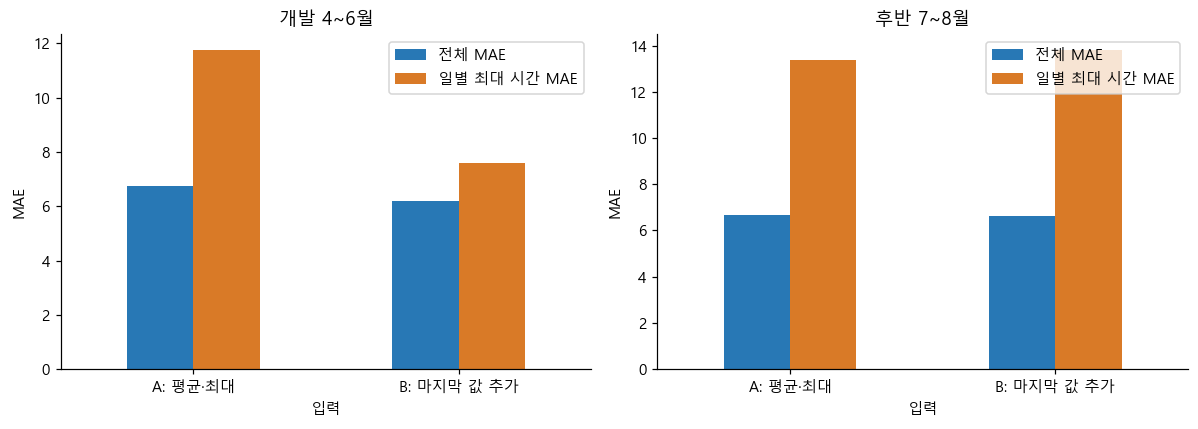

In [21]:
ablation_parts=[]
for month in [4,5,6,7]:
    start=pd.Timestamp(2021,month,1)
    train_ab=development_frame.loc[development_frame.eligible_common&development_frame.timestamp.lt(start)]
    valid_ab=development_frame.loc[development_frame.eligible_common&(development_frame.month.eq(month) if month<7 else development_frame.month.ge(7))]
    for variant,cols in [("A: 평균·최대",basic_features),("B: 마지막 값 추가",basic_features+["lag1_last"])]:
        reg_ab=HistGradientBoostingRegressor(max_leaf_nodes=15,max_iter=150,learning_rate=.05,min_samples_leaf=20,l2_regularization=1.,early_stopping=False,random_state=42)
        reg_ab.fit(train_ab[cols],train_ab.target_maximum)
        part=valid_ab[["timestamp","date"]].copy();part["기간"]="개발 4~6월" if month<7 else "후반 7~8월"
        part["입력"]=variant;part["actual"]=valid_ab.target_maximum;part["prediction"]=reg_ab.predict(valid_ab[cols]);ablation_parts.append(part)
input_predictions=pd.concat(ablation_parts,ignore_index=True)
input_rows=[]
for (period,variant),g in input_predictions.groupby(["기간","입력"]):
    peaks=[metrics(day.loc[day.actual.eq(day.actual.max())])["mae"] for _,day in g.groupby("date") if len(day)==24]
    input_rows.append({"기간":period,"입력":variant,"전체 MAE":metrics(g)["mae"],"일별 최대 시간 MAE":np.mean(peaks),"평가 시간":len(g)})
input_summary=pd.DataFrame(input_rows);show_table(input_summary,"17b_마지막값추가효과")
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,(period,g) in zip(axes,input_summary.groupby("기간")):
    g.set_index("입력")[["전체 MAE","일별 최대 시간 MAE"]].plot.bar(ax=ax,color=COLORS[:2]);ax.set_title(period);ax.set_ylabel("MAE");ax.tick_params(axis="x",rotation=0)
show_figure("17b_입력추가효과")

**결과 해석**

마지막 값은 개발 기간의 오차를 줄이지만, 후반기 일별 최대 시간의 개선은 유지되지 않는다. 따라서 개발의 상관·평균오차 개선을 모든 높은 부하의 개선으로 확대하지 않는다. 다음 절에서는 전력이 크게 올라 유지되기 시작하는 시간에만 상태 정보를 보완하는 방법을 평가한다.

## 4.2 지속 상승 정의와 선택적 HGB 보완

1월에서 고정한 큰 변화 기준과 과거 6시간의 중앙값·IQR로 상승 시작을 정의한다. 미래 3시간은 정답 확인에만 사용하고 입력에는 넣지 않는다. 상태 경과시간은 분류기에서만 제거하고 회귀 B1에서는 유지한다. 아래 함수는 사건 정의와 과거 상태 구성에 필요한 계산이다.

In [22]:
MODEL_SETTINGS = {'onset_definition': {'thresholds': {'up': 59.5, 'down': 42.92499999999997}},
 'logistic': {'C': 1.0,
              'max_iter': 3000,
              'random_state': 42,
              'class_weight': None,
              'standardize': 'training only'},
 'regression_features': {'B0': ['hour_sin',
                                'hour_cos',
                                'month',
                                'weekend',
                                'dow_0',
                                'dow_1',
                                'dow_2',
                                'dow_3',
                                'dow_4',
                                'dow_5',
                                'dow_6',
                                'lag1_production',
                                'lag1_production_zero',
                                'lag1_mean',
                                'lag1_maximum',
                                'lag2_mean',
                                'lag2_maximum',
                                'lag1_last'],
                         'B1': ['hour_sin',
                                'hour_cos',
                                'month',
                                'weekend',
                                'dow_0',
                                'dow_1',
                                'dow_2',
                                'dow_3',
                                'dow_4',
                                'dow_5',
                                'dow_6',
                                'lag1_production',
                                'lag1_production_zero',
                                'lag1_mean',
                                'lag1_maximum',
                                'lag2_mean',
                                'lag2_maximum',
                                'lag1_last',
                                'past_median6',
                                'past_iqr6',
                                'past_range6',
                                'past_slope6',
                                'prior_delta',
                                'prior_last_minus_mean',
                                'prior_slot_range',
                                'prior_production_delta',
                                'prior_state_age',
                                'prior_state_left_censored',
                                'prior_state_direction',
                                'up_classifier_available',
                                'down_classifier_available']},
 'hgb_parameters': {'max_leaf_nodes': 15,
                    'max_iter': 150,
                    'learning_rate': 0.05,
                    'min_samples_leaf': 20,
                    'l2_regularization': 1.0,
                    'early_stopping': False,
                    'random_state': 42},
 'classification_features': ['prior_mean',
                             'past_median6',
                             'past_iqr6',
                             'past_range6',
                             'past_slope6',
                             'prior_delta',
                             'prior_last_minus_mean',
                             'prior_slot_range',
                             'prior_production',
                             'prior_production_delta',
                             'prior_state_left_censored',
                             'prior_state_direction',
                             'hour_sin',
                             'hour_cos',
                             'month',
                             'weekend',
                             'dow_0',
                             'dow_1',
                             'dow_2',
                             'dow_3',
                             'dow_4',
                             'dow_5',
                             'dow_6'],
 'calendar_features': ['hour_sin',
                       'hour_cos',
                       'month',
                       'weekend',
                       'dow_0',
                       'dow_1',
                       'dow_2',
                       'dow_3',
                       'dow_4',
                       'dow_5',
                       'dow_6']}

def label(d, th, multiplier=1.5):
    """Onset identity uses only current/past values; future is used only afterwards."""
    z = d.copy()
    up = z.eligible_onset & z.delta.ge(th["up"]) & z.deviation.ge(th["up"]) & z.deviation.ge(multiplier*z.past_iqr6)
    down = z.eligible_onset & (-z.delta).ge(th["down"]) & (-z.deviation).ge(th["down"]) & (-z.deviation).ge(multiplier*z.past_iqr6)
    candidate = np.select([up, down], [1, -1], default=0)
    starts = np.zeros(len(z), dtype=int)
    ages, censored, directions, available = [], [], [], []
    active = None
    last_gap = None
    event_rows = []
    for i, (ts, row) in enumerate(z.iterrows()):
        # State at t-1, before current t measurement.
        ages.append(i-active["i"] if active else 0)
        directions.append(active["sign"] if active else 0)
        censored.append(int(active is None and (last_gap is None or i-last_gap <= 6)))
        available.append(ts-pd.Timedelta(hours=1))
        if not row.valid:
            active = None
            last_gap = i
            continue
        sign = int(candidate[i])
        if active is not None:
            if active["sign"]*(row.level-active["baseline"]) < .5*th[active["direction"]]:
                active = None
            elif sign and sign != active["sign"]:
                active = None
        if sign and active is None:
            direction = "up" if sign == 1 else "down"
            active = {"i": i, "baseline": row.past_median6, "sign": sign, "direction": direction}
            starts[i] = sign
            event_rows.append({"event_id": len(event_rows)+1, "position": i,
                              "timestamp": ts, "date": row.date, "month": row.month,
                              "hour": row.hour, "weekend": row.weekend,
                              "direction": direction, "baseline": row.past_median6,
                              "first_mean": row.level, "first_maximum": row.maximum,
                              "first_delta": row.delta, "first_deviation": row.deviation,
                              "past_iqr6": row.past_iqr6,
                              "profile": row.profile,
                              "previous_mean": row.prior_mean,
                              "production_before": row.prior_production,
                              "production_at_start": row["생산량"]})
    z["candidate"] = candidate
    z["onset"] = starts
    z["prior_state_age"] = ages
    z["prior_state_direction"] = directions
    z["prior_state_left_censored"] = censored
    z["latest_input_timestamp"] = available
    z["label_confirmed_at"] = z.index + pd.Timedelta(hours=2)
    z["persistence_known"] = z.valid & z.valid.shift(-1, fill_value=False) & z.valid.shift(-2, fill_value=False)
    z["sustained_onset"] = 0.
    z.loc[~z.persistence_known, "sustained_onset"] = np.nan
    for event in event_rows:
        i, direction = event["position"], event["direction"]
        sign = 1 if direction == "up" else -1
        boundary = .5*th[direction]
        n = 0
        while i+n < len(z) and bool(z.valid.iloc[i+n]) and sign*(z.level.iloc[i+n]-event["baseline"]) >= boundary:
            n += 1
        end = i+n
        reason = "scope_end" if end == len(z) else ("gap" if not bool(z.valid.iloc[end]) else "return")
        event["reference_departure_hours"] = n
        event["right_censored"] = reason != "return"
        event["end_reason"] = reason
        event["last_departure_timestamp"] = z.index[i+n-1]
        event["duration_confirmed_at"] = z.index[end] if end < len(z) else pd.NaT
        for horizon in [1, 3, 6]:
            window = z.iloc[i:i+horizon]
            known = len(window) == horizon and bool(window.valid.all())
            sustained = bool((sign*(window.level-event["baseline"]) >= boundary).all()) if known else None
            event[f"sustained{horizon}"] = sustained
        event["label_confirmed_at"] = z.index[i]+pd.Timedelta(hours=2) if event["sustained3"] is not None else pd.NaT
        first3 = z.iloc[i:i+3]
        event["next3_mean"] = float(first3.level.mean()) if event["sustained3"] is not None else np.nan
        event["next3_min_mean"] = float(first3.level.min()) if event["sustained3"] is not None else np.nan
        event["next3_max_mean"] = float(first3.level.max()) if event["sustained3"] is not None else np.nan
        z.iloc[i, z.columns.get_loc("sustained_onset")] = sign if event["sustained3"] else (0. if event["sustained3"] is not None else np.nan)
    events = pd.DataFrame(event_rows)
    return z, events

def add_calendar(f):
    f = f.copy()
    f["hour_sin"] = np.sin(2 * np.pi * f.timestamp.dt.hour / 24)
    f["hour_cos"] = np.cos(2 * np.pi * f.timestamp.dt.hour / 24)
    for i in range(7):
        f[f"dow_{i}"] = (f.timestamp.dt.dayofweek == i).astype(int)
    return f

def build_state_features(c):
    raw = processed_data.copy()
    raw = raw.loc[raw["날짜"].between(20210101, 20210831) & raw["시간"].between(0, 23)].copy()
    raw["timestamp"] = pd.to_datetime(raw["날짜"].astype(str), format="%Y%m%d") + pd.to_timedelta(raw["시간"], unit="h")
    raw = raw.sort_values("timestamp").set_index("timestamp")
    assert raw.index.is_unique
    f = raw.reindex(pd.date_range("2021-01-01", "2021-08-31 23:00", freq="h")); f.index.name = "timestamp"
    slots = ["15분", "30분", "45분", "60분"]
    f["valid"] = f[slots].notna().all(axis=1); f["level"] = f[slots].mean(axis=1).where(f.valid)
    f["maximum"] = f[slots].max(axis=1).where(f.valid)
    f["date"] = f.index.normalize(); f["month"] = f.index.month; f["hour"] = f.index.hour
    f["weekend"] = (f.index.dayofweek >= 5).astype(int)
    profiles = {date: hashlib.sha256(g[slots].to_numpy(dtype=np.int64).tobytes()).hexdigest() for date, g in raw.groupby(raw.index.normalize())}
    f["profile"] = f.date.map(profiles)
    h = pd.concat([f.level.shift(k).rename(str(k)) for k in range(1, 7)], axis=1)
    f["eligible_onset"] = f.valid & h.notna().all(axis=1); f["prior_mean"] = h["1"]
    f["past_median6"] = h.median(axis=1).where(f.eligible_onset)
    f["past_iqr6"] = (h.quantile(.75, axis=1) - h.quantile(.25, axis=1)).where(f.eligible_onset)
    f["past_range6"] = (h.max(axis=1) - h.min(axis=1)).where(f.eligible_onset)
    f["past_slope6"] = ((h["1"] - h["6"]) / 5).where(f.eligible_onset)
    f["prior_delta"] = f.level.shift(1) - f.level.shift(2)
    f["prior_last_minus_mean"] = f["60분"].shift(1) - f.prior_mean
    f["prior_slot_range"] = (f[slots].max(axis=1) - f[slots].min(axis=1)).shift(1).where(f.valid.shift(1, fill_value=False))
    f["prior_production"] = f["생산량"].shift(1); f["prior_production_delta"] = f["생산량"].shift(1) - f["생산량"].shift(2)
    f["delta"] = f.level - f.prior_mean; f["deviation"] = f.level - f.past_median6
    z, events = label(f, c["onset_definition"]["thresholds"])
    return add_calendar(z.reset_index()), events

def classification_model(method, contract):
    if method == "logistic":
        params = {k: v for k, v in contract[method].items() if k != "standardize"}
        return make_pipeline(StandardScaler(), LogisticRegression(**params))
    return HistGradientBoostingClassifier(**contract[method])

def choose_alarm_threshold(y, score):
    # Stable descending order, evaluating all tie groups in a single pass.
    order = np.argsort(-score, kind="stable")
    yy, ss = np.asarray(y)[order], np.asarray(score)[order]
    best = (0, 0, math.inf)
    tp = fp = 0
    cap = math.floor(.01 * int((yy == 0).sum()) + 1e-10)
    for i in range(len(yy)):
        tp += int(yy[i] == 1); fp += int(yy[i] == 0)
        if i + 1 < len(yy) and ss[i + 1] == ss[i]:
            continue
        candidate = (tp, -fp, float(ss[i]))
        if fp <= cap and candidate > best:
            best = candidate
    return best[2], best[0], -best[1], cap


z, events=build_state_features(MODEL_SETTINGS)
show_table(events.groupby(["month","direction"]).agg(시작수=("event_id","size"),지속3시간=("sustained3",lambda x:int(x.eq(True).sum()))).reset_index(),"18_지속사건정의")
print("상승 기준:",MODEL_SETTINGS["onset_definition"]["thresholds"]["up"],"3시간 유지 기준:",MODEL_SETTINGS["onset_definition"]["thresholds"]["up"]/2)

,month,direction,시작수,지속3시간
0,1,down,21,11
1,1,up,12,6
2,2,down,22,8
3,3,down,23,9
4,3,up,4,4
5,4,down,13,5
6,4,up,6,6
7,5,down,15,6
8,5,up,8,8
9,6,down,18,4


상승 기준: 59.5 3시간 유지 기준: 29.75


**정의와 해석**

시간 평균이 직전 평균과 과거 6시간 중앙값보다 각각 59.5 이상 높고, 중앙값 대비 상승폭이 과거 IQR의 1.5배 이상인 시작을 후보로 삼는다. 이후 3시간이 기존 기준선보다 29.75 이상 높게 유지되면 지속 상승이다. 계속되는 같은 방향 상태는 새로운 시작으로 중복 집계하지 않는다. 분류 정답은 t+2에 확인되므로 학습 경계 이전에 확인된 정답만 사용한다.

### 과거 OOF 경계 산정과 고정 모델 학습

4·5·6월 예측은 각각 그 월 이전의 확인된 정답으로만 학습한다. 이 OOF 예측에서 음성 오경보율 1% 이내의 경계를 정한다. 1~6월 분류와 2~6월 회귀를 고정해 7~8월의 입력만 갱신한다.

In [23]:
features=MODEL_SETTINGS["classification_features"]
ct=z.loc[z.eligible_onset & z.persistence_known & z.label_confirmed_at.lt("2021-07-01")].copy()
oof_parts=[]
for month in [4,5,6]:
    boundary_month=pd.Timestamp(2021,month,1)
    tr=ct.loc[ct.label_confirmed_at.lt(boundary_month)];te=ct.loc[ct.month.eq(month)]
    fit=classification_model("logistic",MODEL_SETTINGS)
    fit.fit(tr[features],tr.sustained_onset.eq(1).astype(int))
    p=te[["timestamp","label_confirmed_at","sustained_onset"]].copy()
    p["score"]=fit.predict_proba(te[features])[:,1];p["event"]=te.sustained_onset.eq(1).astype(int);oof_parts.append(p)
oof=pd.concat(oof_parts)
alarm_boundary,oof_tp,oof_fp,fp_cap=choose_alarm_threshold(oof.event.to_numpy(int),oof.score.to_numpy(float))
clf=classification_model("logistic",MODEL_SETTINGS);clf.fit(ct[features],ct.sustained_onset.eq(1).astype(int))
late=z.loc[z.eligible_onset & z.month.ge(7)].copy()
score=clf.predict_proba(late[features])[:,1]
base=MODEL_SETTINGS["regression_features"]["B0"];expanded=MODEL_SETTINGS["regression_features"]["B1"]
extras=[n for n in expanded if n not in base and not n.endswith("classifier_available")]
zh=pd.read_csv(io.StringIO(z.loc[z.month.le(6)].to_csv(index=False)),parse_dates=["timestamp","label_confirmed_at"])
zz=pd.concat([zh,z.loc[z.month.ge(7)]],ignore_index=True)
common=zz.loc[zz.eligible_onset,["timestamp","label_confirmed_at","month","profile","sustained_onset","persistence_known"]+extras]
common=common.drop(columns="month").merge(model_frame.loc[model_frame.eligible_common,["timestamp","target_maximum"]+base],on="timestamp",validate="one_to_one")
for direction,sign in [("up",1),("down",-1)]:
    availability={}
    for month in range(2,9):
        mature=ct.loc[ct.label_confirmed_at.lt(pd.Timestamp(2021,min(month,7),1))]
        positive=mature.loc[mature.sustained_onset.eq(sign)]
        availability[month]=int(len(positive)>=8 and positive.date.nunique()>=5)
    common[direction+"_classifier_available"]=common.month.map(availability)
rt=common.loc[common.month.between(2,6)&common.persistence_known&common.label_confirmed_at.lt("2021-07-01")]
rt=pd.read_csv(io.StringIO(rt.to_csv(index=False)),parse_dates=["timestamp","label_confirmed_at"])
test=common.loc[common.month.ge(7)].copy()
predictions={}
for variant,cols in [("B0",base),("B1_all",expanded)]:
    reg=HistGradientBoostingRegressor(**MODEL_SETTINGS["hgb_parameters"])
    reg.fit(rt[cols],rt.target_maximum);predictions[variant]=reg.predict(test[cols])
scores_index=pd.Series(score,index=late.timestamp)
alarm=scores_index.loc[test.timestamp].to_numpy()>=alarm_boundary
predictions["G1_noage"]=np.where(alarm,predictions["B1_all"],predictions["B0"])
replay=pd.concat([test[["timestamp","sustained_onset"]].assign(variant=name,actual=test.target_maximum,prediction=pred) for name,pred in predictions.items()],ignore_index=True)
show_table(pd.DataFrame({"항목":["분류 학습","회귀 학습","7~8월 분류 예측","공통 회귀 시간","OOF 경계","OOF 적중","OOF 오경보"],
    "값":[len(ct),len(rt),len(late),len(test),alarm_boundary,oof_tp,oof_fp]}),"19_모델학습경계")

,항목,값
0,분류 학습,4336.0000
1,회귀 학습,3598.0000
2,7~8월 분류 예측,1428.0000
3,공통 회귀 시간,1344.0000
4,OOF 경계,0.4555
5,OOF 적중,18.0000
6,OOF 오경보,0.0000


**학습 결과**

분류 4,336시간·회귀 3,598시간을 학습하고 분류 1,428개·회귀 3방법×1,344개 예측을 생성한다. OOF 경계는 약 0.4555다. 평가 월의 정답으로 경계를 변경하거나 7월 자료로 재학습하지 않는다. 경고가 있을 때만 B1을 선택하며 나머지는 B0를 사용한다.

### 선택적 보완의 오차와 탐지 결과

동일한 1,344시간에서 전체·상승 시작·일별 최대 시간 오차를 비교한다. 정답이 확인된 행에서만 분류 정밀도·재현율을 계산한다.

,방법,hours,events,tp,fp,fn,tn,recall,precision,fpr,ap
0,경과시간 포함,1340,13,7,38,6,1289,0.5385,0.1556,0.0286,0.5583
1,경과시간 제거,1340,13,7,0,6,1327,0.5385,1.0000,0.0000,0.6315


,방법,조건,hours,mae,rmse,bias,under,over
0,B0,전체,1344,6.3349,9.7159,-0.6185,3.4767,2.8582
1,B0,상승 시작,13,20.0368,24.1768,-18.8012,19.4190,0.6178
2,B0,일별 최대 시간,77,13.1792,NaN,-12.3618,12.7705,0.4087
3,B1_all,전체,1344,7.9940,11.3767,1.1629,3.4156,4.5784
4,B1_all,상승 시작,13,18.7817,22.0008,-15.0539,16.9178,1.8639
5,B1_all,일별 최대 시간,77,13.5245,NaN,-10.1253,11.8249,1.6996
6,G1_noage,전체,1344,6.3172,9.6511,-0.5767,3.4470,2.8703
7,G1_noage,상승 시작,13,18.2054,21.3246,-14.4777,16.3416,1.8639
8,G1_noage,일별 최대 시간,77,12.5741,NaN,-11.7567,12.1654,0.4087


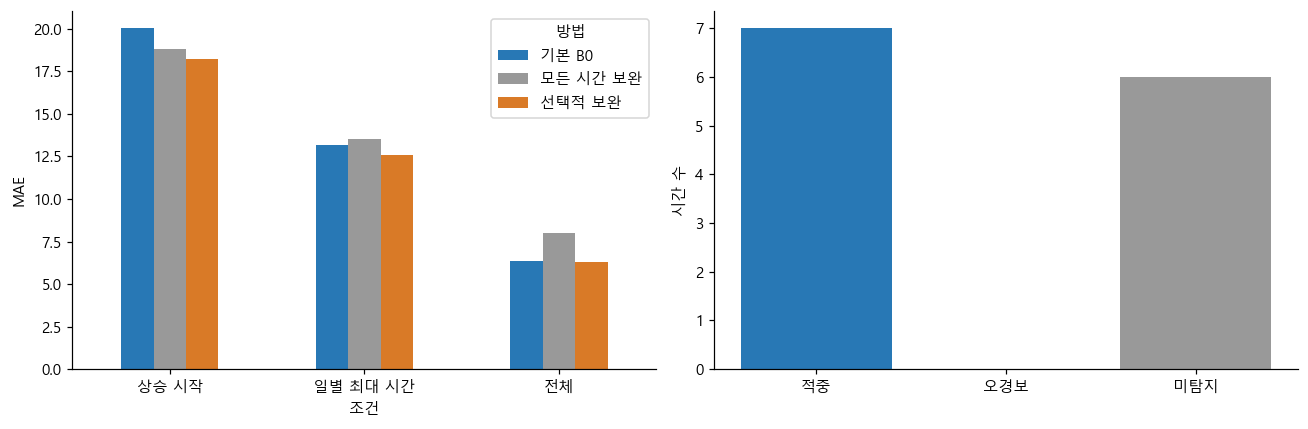

In [24]:
def detection(g):
    y, a = g.event.to_numpy(int), g.alarm.to_numpy(int)
    tp = int(((y == 1) & (a == 1)).sum()); fp = int(((y == 0) & (a == 1)).sum())
    fn = int(y.sum()) - tp; tn = len(g) - int(y.sum()) - fp
    return {"hours": len(g), "events": int(y.sum()), "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "recall": tp / (tp + fn) if tp + fn else None, "precision": tp / (tp + fp) if tp + fp else None,
            "fpr": fp / (fp + tn) if fp + tn else None, "ap": float(average_precision_score(y, g.score)) if y.sum() else None}


classification=late[["timestamp","sustained_onset","persistence_known"]].copy()
classification["score"]=score;classification["alarm"]=(score>=alarm_boundary).astype(int)
classification["event"]=classification.sustained_onset.eq(1).astype(int)
class_common=classification.loc[classification.timestamp.isin(test.timestamp)&classification.persistence_known]
det=detection(class_common)
features_original=features.copy()
features_original.insert(features_original.index("prior_state_left_censored"),"prior_state_age")
original_clf=classification_model("logistic",MODEL_SETTINGS)
original_train=pd.read_csv(io.StringIO(ct.to_csv(index=False)))
original_clf.fit(original_train[features_original],original_train.sustained_onset.eq(1).astype(int))
original_score=original_clf.predict_proba(late[features_original])[:,1]
original_class=classification.assign(score=original_score,alarm=(original_score>=.2244084160368694).astype(int))
original_common=original_class.loc[original_class.timestamp.isin(test.timestamp)&original_class.persistence_known]
show_table(pd.DataFrame([{"방법":"경과시간 포함",**detection(original_common)},{"방법":"경과시간 제거",**det}]),"20_공통범위분류성능")
assert detection(original_common)["fp"]==38
regression_rows=[]
for name,g in replay.groupby("variant"):
    for condition,p in [("전체",g),("상승 시작",g.loc[g.sustained_onset.eq(1)])]:
        regression_rows.append({"방법":name,"조건":condition,**metrics(p)})
    daily=[]
    for date,day in g.groupby(g.timestamp.dt.normalize()):
        if len(day)==24: daily.append(metrics(day.loc[day.actual.eq(day.actual.max())]))
    regression_rows.append({"방법":name,"조건":"일별 최대 시간", "hours":sum(d["hours"] for d in daily),
                            **{k:np.mean([d[k] for d in daily]) for k in ["mae","under","over","bias"]}})
regression_summary=pd.DataFrame(regression_rows);show_table(regression_summary,"20_회귀오차")
fig,axes=plt.subplots(1,2,figsize=(12,4))
regression_summary.pivot(index="조건",columns="방법",values="mae").rename(columns={"B0":"기본 B0","B1_all":"모든 시간 보완","G1_noage":"선택적 보완"}).plot.bar(ax=axes[0],color=[COLORS[0],"#999999",COLORS[1]])
axes[0].set_ylabel("MAE");axes[0].tick_params(axis="x",rotation=0)
axes[1].bar(["적중","오경보","미탐지"],[det["tp"],det["fp"],det["fn"]],color=[COLORS[0],COLORS[1],"#999999"])
axes[1].set_ylabel("시간 수");show_figure("20_성능과탐지")
replay.to_csv(OUTPUT/"모델별_테스트예측.csv",index=False,encoding="utf-8-sig")
final_predictions=test[["timestamp","target_maximum"]].rename(columns={"target_maximum":"actual_maximum"}).copy()
final_predictions["baseline_prediction"]=predictions["B0"];final_predictions["supplement_prediction"]=predictions["B1_all"]
final_predictions["final_prediction"]=predictions["G1_noage"];final_predictions["alarm"]=alarm.astype(int)
final_predictions.to_csv(PACKAGE/"테스트데이터_예측결과.csv",index=False,encoding="utf-8-sig")

**결과 해석**

상승 시작 MAE는 20.037→18.205(9.1% 감소), 과소예측은 19.419→16.342(15.8% 감소)다. 일별 최대 시간 MAE는 13.179→12.574, 전체는 6.335→6.317이다. 7시간만 보완하고 TP 7·FP 0·FN 6이므로 정밀도 100%, 재현율 53.8%다. 경과시간 제거는 이미 후반기 결과를 본 뒤의 수정이므로 이 개선은 탐색적 재평가로 해석한다.

## 4.3 오류 해석·사례와 현장 활용

Logistic의 표준화 입력×계수를 더해 로짓을 정확히 분해한다. 적중·미탐지 사례는 개선폭과 실제 최대값의 중앙 순위로 선정한다. 사례를 대표 성능으로 일반화하지 않는다.

,조건,시간 수,달력,생산,상태,과거 전력,절편,로짓
0,적중 상승,7,0.3002,0.0445,-0.0894,13.8567,-10.1038,4.0082
1,미탐지 상승,6,-1.2202,0.1760,-0.3492,4.1587,-10.1038,-7.3386


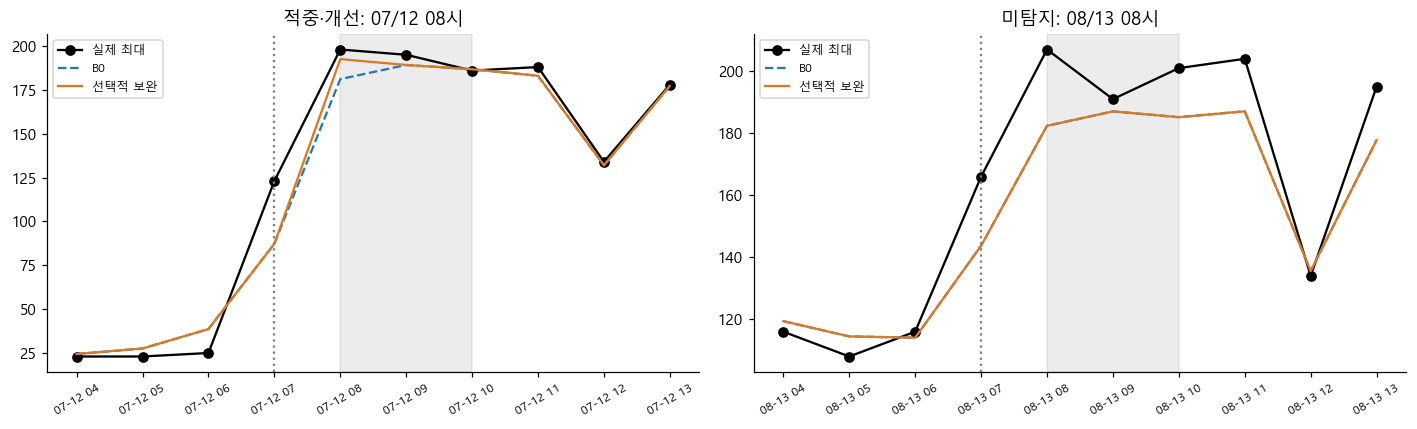

C:\Users\swoo6\AppData\Local\Temp\ipykernel_32432\920274431.py:49: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(frame.round(4))


,사례,시각,실제,B0,보완,선정 후보
0,적중·개선,2021-07-12 08:00:00,198,181.1294,192.5217,4
1,미탐지,2021-08-13 08:00:00,207,182.4036,182.4036,6


,방법,hours,events,tp,fp,fn,tn,recall,precision,fpr,ap
0,고정 분류,1340,13,7,0,6,1327,0.5385,1.0000,0.0000,0.6315
1,사후 월요일 08시 규칙,1340,13,8,1,5,1326,0.6154,0.8889,0.0008,0.6315


In [25]:
scaler,linear=clf[0],clf[1]
contrib=scaler.transform(late[features])*linear.coef_[0]
logit=float(linear.intercept_[0])+contrib.sum(axis=1)
np.testing.assert_allclose(logit,clf.decision_function(late[features]),atol=1e-10)
groups={"달력":[n for n in features if n in MODEL_SETTINGS["calendar_features"]],"생산":["prior_production","prior_production_delta"],"상태":["prior_state_left_censored","prior_state_direction"]}
groups["과거 전력"]=[n for n in features if n not in sum(groups.values(),[])]
explained=classification.copy()
for name,names in groups.items(): explained[name]=contrib[:,[features.index(n) for n in names]].sum(axis=1)
explained["절편"]=float(linear.intercept_[0]);explained["로짓"]=logit
common_explained=explained.loc[explained.timestamp.isin(test.timestamp)&explained.persistence_known]
contribution_summary=pd.DataFrame([{"조건":name,"시간 수":len(g),**{col:g[col].mean() for col in list(groups)+["절편","로짓"]}}
    for name,g in [("적중 상승",common_explained.loc[common_explained.event.eq(1)&common_explained.alarm.eq(1)]),
                   ("미탐지 상승",common_explained.loc[common_explained.event.eq(1)&common_explained.alarm.eq(0)])]])
show_table(contribution_summary,"21_로짓기여")
b0=replay.loc[replay.variant.eq("B0")].set_index("timestamp")
g1=replay.loc[replay.variant.eq("G1_noage")].set_index("timestamp")
event_errors=common_explained.loc[common_explained.event.eq(1)].copy()
event_errors["actual"]=b0.loc[event_errors.timestamp,"actual"].to_numpy()
event_errors["gain"]=(b0.actual-b0.prediction).abs().loc[event_errors.timestamp].to_numpy()-(g1.actual-g1.prediction).abs().loc[event_errors.timestamp].to_numpy()
fig,axes=plt.subplots(1,2,figsize=(13,4));case_rows=[]
for ax,(name,pool,sortcol) in zip(axes,[("적중·개선",event_errors.loc[event_errors.alarm.eq(1)&event_errors.gain.gt(0)],"gain"),("미탐지",event_errors.loc[event_errors.alarm.eq(0)],"actual")]):
    pool=pool.loc[pool.timestamp.map(lambda t:pd.date_range(t-pd.Timedelta(hours=4),t+pd.Timedelta(hours=5),freq="h").isin(b0.index).all())].sort_values([sortcol,"timestamp"])
    chosen=pool.iloc[len(pool)//2];t=chosen.timestamp;times=pd.date_range(t-pd.Timedelta(hours=4),t+pd.Timedelta(hours=5),freq="h")
    ax.plot(times,b0.loc[times,"actual"],color="black",marker="o",label="실제 최대")
    ax.plot(times,b0.loc[times,"prediction"],color=COLORS[0],ls="--",label="B0")
    ax.plot(times,g1.loc[times,"prediction"],color=COLORS[1],label="선택적 보완")
    ax.axvspan(t,t+pd.Timedelta(hours=2),color="gray",alpha=.15);ax.axvline(t-pd.Timedelta(hours=1),color="gray",ls=":")
    ax.set_title(f"{name}: {t:%m/%d %H시}");ax.tick_params(axis="x",rotation=30,labelsize=8);ax.legend(fontsize=8)
    case_rows.append({"사례":name,"시각":t,"실제":b0.loc[t,"actual"],"B0":b0.loc[t,"prediction"],"보완":g1.loc[t,"prediction"],"선정 후보":len(pool)})
show_figure("21_개선과미탐지사례");show_table(pd.DataFrame(case_rows),"21_사례선정")
calendar_alarm=class_common.timestamp.dt.dayofweek.eq(0)&class_common.timestamp.dt.hour.eq(8)
calendar_control=class_common.assign(alarm=calendar_alarm.astype(int))
show_table(pd.DataFrame([{"방법":"고정 분류",**detection(class_common)},{"방법":"사후 월요일 08시 규칙",**detection(calendar_control)}]),"21_사후달력규칙")

**결과 해석**

적중·미탐지의 과거 전력 평균 로짓 기여는 13.86·4.16이다. 기여는 확률의 퍼센트가 아니며 인과효과도 아니다. 7/12의 실제 최대 198은 181.13→192.52로 개선되지만 8/13의 실제 207은 경고 없이 182.40으로 과소예측한다. 경고는 모두 월요일 08시에 집중되고 사후 주간 규칙도 TP 8·FP 1로 비슷하다. 무경고를 안전 판정으로 사용하지 않는다. 실제 가동 조정·전력·비용 절감은 검증된 성과가 아닌 활용 제안이다.

### 재현 확인과 제출 산출물

현재 원자료 재학습 예측을 원고에 사용한 고정 결과와 대조한다. 예측 파일·표·그림은 이 노트북 실행으로 생성된다.

In [26]:
reference_class=pd.read_csv(PACKAGE/"reference/고정_분류예측.csv",encoding="utf-8-sig",parse_dates=["timestamp"])
reference_class=reference_class.loc[reference_class.method.eq("noage")].set_index("timestamp").loc[late.timestamp]
np.testing.assert_allclose(score,reference_class.score,atol=1e-8,rtol=1e-9)
np.testing.assert_array_equal(score>=alarm_boundary,reference_class.alarm)
reference_reg=pd.read_csv(PACKAGE/"reference/고정_회귀예측.csv",encoding="utf-8-sig",parse_dates=["timestamp"])
max_difference=0.
for variant,pred in predictions.items():
    ref=reference_reg.loc[reference_reg.variant.eq(variant)].set_index("timestamp").loc[test.timestamp]
    np.testing.assert_allclose(pred,ref.prediction,atol=1e-8,rtol=1e-9)
    max_difference=max(max_difference,float(np.max(abs(pred-ref.prediction.to_numpy()))))
assert len(ct)==4336 and len(rt)==3598 and len(late)==1428 and len(test)==1344
assert det["tp"]==7 and det["fp"]==0 and det["fn"]==6
verification=pd.DataFrame({"검증":["원자료 정상 시간","분류 예측 대조","회귀 예측 대조","회귀 최대 차이","제출 예측 파일 행"],
    "결과":[len(data),len(score),len(replay),max_difference,len(final_predictions)]})
show_table(verification,"22_재현검증")
print("제출 예측 파일:","테스트데이터_예측결과.csv")
print("전체 계산 완료. 표·그림은 output/, 전처리 자료는 data/processed/에 저장했습니다.")

,검증,결과
0,원자료 정상 시간,5784.0
1,분류 예측 대조,1428.0
2,회귀 예측 대조,4032.0
3,회귀 최대 차이,0.0
4,제출 예측 파일 행,1344.0


제출 예측 파일: 테스트데이터_예측결과.csv
전체 계산 완료. 표·그림은 output/, 전처리 자료는 data/processed/에 저장했습니다.


**결과 해석**

현재 방법의 원자료 → 전처리 → 시차·정답 구성 → 학습·OOF 경계 → 예측을 재실행해 기존 분류 1,428개·회귀 4,032개 예측과 대조한다. 저장 참조 예측은 검증용이며 현재 모델 학습의 입력이 아니다. 신규 환경 설치나 과거 Optuna 전체 재탐색을 완료했다는 뜻은 아니다.